### Granular TBNN
stress = f(D, D^2)

In [ ]:
"""
Granular Constitutive TBNN — 2D (xx, yy, xy only)
Model: sigma = a0*I + a1*D + a2*D^2
       a0, a1, a2 = MLP(I2_D, epsilon)
       I2_D = second invariant of D (2D), epsilon = volumetric strain
"""

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
import numpy as np

SYM_IJ = [(0, 0), (1, 1), (0, 1)]   # xx, yy, xy


# =============================================================================
# SYMLOG
# =============================================================================

def symlog(x, c):
    """Sign-preserving log-linear transform."""
    return np.sign(x) * np.log1p(np.abs(x) / c)


# =============================================================================
# INERTIAL NUMBER MASK
# =============================================================================

def compute_inertial_mask(D_dim, p_hydro, d_particle=0.01, rho=2600.0, I_threshold=1e-5):
    """
    D_dim   : [N, 2, 2]  dimensional strain rate
    p_hydro : [N]        hydrostatic pressure
    Returns bool mask [N], True = active shear (I > threshold)
    """
    trD2     = D_dim[:, 0, 0]**2 + D_dim[:, 1, 1]**2 + 2.0 * D_dim[:, 0, 1]**2
    gd_local = np.sqrt(2.0 * trD2)
    p_safe   = np.clip(p_hydro, 1e-8, None)
    I        = gd_local * d_particle / np.sqrt(p_safe / rho)
    mask     = I > I_threshold
    print(f"  Inertial mask (I>{I_threshold}): {mask.sum():,} / {len(mask):,} "
          f"({100.0 * mask.mean():.1f}% retained)")
    return mask


# =============================================================================
# DATA PROCESSOR
# =============================================================================

class GranularDataProcessor:

    def __init__(self):
        self._c_I2     = None
        self._c_eps    = None
        self._xa_mean  = None
        self._xa_std   = None
        self._sp_clip_lo = None
        self._sp_clip_hi = None
        self._sp_var     = None

    # ── scalar invariants ───────────────────────────────────────────────────

    def calc_scalar_basis(self, D, epsilon, is_train=True):
        """
        D       : [N, 2, 2]  non-dimensional strain rate
        epsilon : [N]        volumetric strain
        Returns x_a_raw [N,2], x_a_sc [N,2] (scaled inputs for MLP)
        """
        trD  = D[:, 0, 0] + D[:, 1, 1]                      # tr(D)
        D2   = np.einsum('nij,njk->nik', D, D)               # D^2
        trD2 = D2[:, 0, 0] + D2[:, 1, 1]                    # tr(D^2)
        I2_D = 0.5 * (trD**2 - trD2)                         # second invariant of D

        x_a_raw = np.nan_to_num(np.stack([I2_D, epsilon], axis=1))  # [N, 2]

        # symlog scale constants from training data
        if is_train:
            def _c(col):
                vals = np.abs(col[col != 0])
                return float(np.percentile(vals, 10)) if len(vals) > 0 else 1e-4
            self._c_I2  = _c(x_a_raw[:, 0])
            self._c_eps = _c(x_a_raw[:, 1])
            print(f"  symlog c: I2={self._c_I2:.2e}  eps={self._c_eps:.2e}")

        x_a_sym = np.stack([symlog(x_a_raw[:, 0], self._c_I2),
                             symlog(x_a_raw[:, 1], self._c_eps)], axis=1)

        if is_train:
            self._xa_mean = x_a_sym.mean(0)
            self._xa_std  = x_a_sym.std(0).clip(1e-8)

        x_a_sc = (x_a_sym - self._xa_mean) / self._xa_std
        return x_a_raw, x_a_sc

    # ── tensor basis ────────────────────────────────────────────────────────

    def calc_tensor_basis(self, D):
        """
        Returns tb [N, 3, 2, 2] = [I, D, D^2]
        """
        N   = D.shape[0]
        I   = np.eye(2)[None].repeat(N, axis=0)              # [N, 2, 2]
        D2  = np.einsum('nij,njk->nik', D, D)                # [N, 2, 2]
        return np.stack([I, D, D2], axis=1)                  # [N, 3, 2, 2]

    # ── output: non-dimensionalise sigma ───────────────────────────────────

    def calc_output(self, sigma, is_train=True, clip_percentile=99.5):
        """
        sigma : [N, 2, 2]  raw stress (Pa or simulation units)
        Returns sp3 [N, 3] = (sigma_xx, sigma_yy, sigma_xy) * scale
        No traceless decomposition — pure sigma, only non-dimensionalised.
        """
        kn    = 1e5
        dp    = 0.01
        scale = dp / kn

        sp3 = np.stack([sigma[:, i, j] for i, j in SYM_IJ], axis=1) * scale  # [N, 3]
        sp3 = np.nan_to_num(sp3)

        if is_train:
            self._sp_clip_lo = np.percentile(sp3, 100 - clip_percentile, axis=0)
            self._sp_clip_hi = np.percentile(sp3, clip_percentile,       axis=0)

        sp3 = np.clip(sp3, self._sp_clip_lo, self._sp_clip_hi)

        if is_train:
            self._sp_var = sp3.var(0) + 1e-8
            for k, (i, j) in enumerate(SYM_IJ):
                print(f"  sigma*[{i},{j}]: mean={sp3[:, k].mean():+.5f}  "
                      f"std={np.sqrt(self._sp_var[k]):.5f}")

        return sp3


# =============================================================================
# NETWORK
# =============================================================================

def _build_mlp(n_in, n_out, num_layers, num_nodes):
    layers, d = [], n_in
    for _ in range(num_layers):
        layers += [nn.Linear(d, num_nodes), nn.LayerNorm(num_nodes), nn.GELU()]
        d = num_nodes
    layers.append(nn.Linear(d, n_out))
    nn.init.xavier_uniform_(layers[-1].weight, gain=0.05)
    nn.init.zeros_(layers[-1].bias)
    return nn.Sequential(*layers)


class NetworkStructure:
    def __init__(self):
        self.num_layers       = 3
        self.num_nodes        = 64
        self.max_epochs       = 3000
        self.min_epochs       = 500
        self.interval         = 100
        self.average_interval = 4
        self.learning_rate    = 1e-3
        self.batch_size       = 512
        self.split_fraction   = 0.8
        self.seed             = 42
        self.lambda_coeff     = 0.01
        self.w_sp             = 1.0

    def set_num_layers(self, n): self.num_layers = n
    def set_num_nodes(self,  n): self.num_nodes  = n
    def set_max_epochs(self, n): self.max_epochs = n
    def set_min_epochs(self, n): self.min_epochs = n


class GranularTBNN(nn.Module):
    """
    sigma_pred = a0*I + a1*D + a2*D^2
    a0, a1, a2 = MLP(I2_D, epsilon)    scalars, functions of invariants only
    """

    def __init__(self, structure):
        super().__init__()
        self.coeff_mlp = _build_mlp(2, 3, structure.num_layers, structure.num_nodes)

    def forward(self, x_a, tb):
        """
        x_a : [N, 2]       scaled scalar inputs (I2_D, epsilon)
        tb  : [N, 3, 2, 2] tensor basis [I, D, D^2]
        Returns sigma_pred [N,2,2], coeffs [N,3]
        """
        coeffs = self.coeff_mlp(x_a)                        # [N, 3]

        a0 = coeffs[:, 0].view(-1, 1, 1)
        a1 = coeffs[:, 1].view(-1, 1, 1)
        a2 = coeffs[:, 2].view(-1, 1, 1)

        I_mat = tb[:, 0]   # [N, 2, 2]
        D_mat = tb[:, 1]   # [N, 2, 2]
        D2_mat = tb[:, 2]  # [N, 2, 2]

        sigma_pred = a0 * I_mat + a1 * D_mat + a2 * D2_mat  # [N, 2, 2]

        return sigma_pred, coeffs


# =============================================================================
# TRAINER
# =============================================================================

class GranularTBNNTrainer:

    def __init__(self, model, processor, structure,
                 device='cuda' if torch.cuda.is_available() else 'cpu'):
        self.model     = model.to(device)
        self.processor = processor
        self.structure = structure
        self.device    = device
        self.history   = {k: [] for k in
                          ['total', 'loss_sp', 'loss_reg', 'val_total']}

    def _make_loader(self, *arrays, shuffle=True):
        tensors = [torch.from_numpy(np.ascontiguousarray(a)).float() for a in arrays]
        return DataLoader(TensorDataset(*tensors),
                          batch_size=self.structure.batch_size,
                          shuffle=shuffle, num_workers=0, pin_memory=False)

    @staticmethod
    def _relative_huber(pred, true, var):
        """Element-wise relative squared error, averaged."""
        denom = (true+1e-6)**2  # avoid div-by-zero when true≈0
        err   = (pred - true)**2 / denom
        return err.mean()

    def fit(self, x_a, tb, sp3_true, print_every=100):
        struct  = self.structure
        N       = x_a.shape[0]
        tb_flat = tb.reshape(N, -1)                          # [N, 12]

        rng     = np.random.default_rng(struct.seed)
        idx     = rng.permutation(N)
        N_train = int(N * struct.split_fraction)
        tr, va  = idx[:N_train], idx[N_train:]

        # loader has 3 arrays: x_a, tb_flat, sp3_true
        tr_loader = self._make_loader(x_a[tr],  tb_flat[tr],  sp3_true[tr])
        va_loader = self._make_loader(x_a[va],  tb_flat[va],  sp3_true[va], shuffle=False)

        opt      = torch.optim.Adam(self.model.parameters(), lr=struct.learning_rate)
        lr_sched = torch.optim.lr_scheduler.ReduceLROnPlateau(
                       opt, mode='min', factor=0.5, patience=5, min_lr=1e-6)

        sp_var = torch.tensor(self.processor._sp_var, dtype=torch.float32,
                              device=self.device)  # [3]

        val_window = []

        for epoch in range(struct.max_epochs):
            ep = {k: 0.0 for k in ['total', 'loss_sp', 'loss_reg']}
            nb = 0
            self.model.train()

            for xab, tbb, spb in tr_loader:
                xab = xab.to(self.device)
                tbb = tbb.to(self.device).view(-1, 3, 2, 2)  # [B, 3, 2, 2]
                spb = spb.to(self.device)

                sigma_pred, coeffs = self.model(xab, tbb)

                # extract (xx, yy, xy) from predicted [B,2,2]
                sp3_pred = torch.stack([sigma_pred[:, i, j] for i, j in SYM_IJ], dim=1)

                loss_sp  = self._relative_huber(sp3_pred, spb, sp_var)
                loss_reg = struct.lambda_coeff * (coeffs**2).mean()
                total    = struct.w_sp * loss_sp + loss_reg

                opt.zero_grad()
                total.backward()

                grad_ok = all(
                    p_.grad is not None and torch.isfinite(p_.grad).all()
                    for p_ in self.model.parameters() if p_.requires_grad)
                if not grad_ok:
                    opt.zero_grad()
                    continue

                torch.nn.utils.clip_grad_norm_(self.model.parameters(), 1.0)
                opt.step()

                ep['total']    += total.item()
                ep['loss_sp']  += loss_sp.item()
                ep['loss_reg'] += loss_reg.item()
                nb += 1

            if nb == 0:
                print(f"Epoch {epoch + 1}: all batches NaN — stopping.")
                break

            for k in ep:
                self.history[k].append(ep[k] / nb)

            if (epoch + 1) % struct.interval == 0:
                vl = self._eval_loss(va_loader, sp_var)
                val_window.append(vl)
                self.history['val_total'].append(vl)
                lr_sched.step(vl)

                if (epoch >= struct.min_epochs
                        and len(val_window) >= struct.average_interval * 2):
                    recent = np.mean(val_window[-struct.average_interval:])
                    older  = np.mean(val_window[-(struct.average_interval * 2)
                                                : -struct.average_interval])
                    if older > 1e-6 and (older - recent) / older < 1e-3:
                        print(f"Early stopping at epoch {epoch + 1}.")
                        break

            if (epoch + 1) % print_every == 0:
                print(f"Epoch {epoch + 1:5d} | total={self.history['total'][-1]:.4f} | "
                      f"sp={self.history['loss_sp'][-1]:.4f} | "
                      f"reg={self.history['loss_reg'][-1]:.4f} | "
                      f"lr={opt.param_groups[0]['lr']:.2e}")

    @torch.no_grad()
    def _eval_loss(self, loader, sp_var):
        self.model.eval()
        total, n = 0.0, 0
        for xab, tbb, spb in loader:                         # ← 3 tensors only
            xab = xab.to(self.device)
            tbb = tbb.to(self.device).view(-1, 3, 2, 2)     # ← [B, 3, 2, 2]
            spb = spb.to(self.device)

            sigma_pred, coeffs = self.model(xab, tbb)
            sp3_pred = torch.stack([sigma_pred[:, i, j] for i, j in SYM_IJ], dim=1)

            loss_sp = self._relative_huber(sp3_pred, spb, sp_var)
            loss_r  = self.structure.lambda_coeff * (coeffs**2).mean()
            total  += (self.structure.w_sp * loss_sp + loss_r).item()
            n      += 1

        self.model.train()
        return total / max(n, 1)

    @torch.no_grad()
    def predict(self, x_a, tb):
        self.model.eval()
        N   = x_a.shape[0]
        xat = torch.from_numpy(np.ascontiguousarray(x_a)).float().to(self.device)
        tbt = torch.from_numpy(np.ascontiguousarray(tb.reshape(N, -1))).float().to(self.device)
        tbt = tbt.view(N, 3, 2, 2)                          # ← [N, 3, 2, 2]

        sigma_pred, coeffs = self.model(xat, tbt)
        sp3 = torch.stack([sigma_pred[:, i, j] for i, j in SYM_IJ], dim=1)

        self.model.train()
        return sp3.cpu().numpy(), sigma_pred.cpu().numpy(), coeffs.cpu().numpy()

    @staticmethod
    def rmse(y_true, y_pred):
        return float(np.sqrt(np.mean((y_true - y_pred)**2)))


# =============================================================================
# DATA LOADING
# =============================================================================

TIME_START = 35
Y_SLICE    = slice(5, 35)
#{'014': 0.035, '003': 0.00775, '03': 0.0775,'085': 0.2125, '14': 0.35,}
DATASETS = [
    dict(tag="vf601_vt085", gamma_dot=0.2125,
         sigma  =r"D:\ml_granular\Sparse Modeling\DAY-TAH\CG_stress_Tensor_vf601vt085.pt",
         deform =r"D:\ml_granular\Sparse Modeling\DAY-TAH\deformation_tensorvf601vt085.pt",
         epsilon=r"D:\ml_granular\Sparse Modeling\DAY-TAH\cg_strains_601_085.pt"),
    dict(tag="vf601_vt03", gamma_dot=0.0775,
         sigma  =r"D:\ml_granular\Sparse Modeling\DAY-TAH\CG_stress_Tensor_vf601vt03.pt",
         deform =r"D:\ml_granular\Sparse Modeling\DAY-TAH\deformation_tensorvf601vt03.pt",
         epsilon=r"D:\ml_granular\Sparse Modeling\DAY-TAH\cg_strains_601_03.pt"),
]


def load_and_nondim(entry):
    gd = entry["gamma_dot"]

    sig_raw = torch.load(entry["sigma"],   weights_only=False).numpy()
    def_raw = torch.load(entry["deform"],  weights_only=False).numpy()
    eps_raw = torch.load(entry["epsilon"], weights_only=False).numpy()

    T, Gx, Gy, Gz = eps_raw.shape
    sig_raw = sig_raw.reshape(T, Gx, Gy, Gz, 3, 3)
    def_raw = def_raw.reshape(T, Gx, Gy, Gz, 3, 3)

    sig_raw = sig_raw[TIME_START:, :, Y_SLICE, :]
    def_raw = def_raw[TIME_START:, :, Y_SLICE, :]
    eps_raw = eps_raw[TIME_START:, :, Y_SLICE, :]

    p_hydro  = -(sig_raw[..., 0, 0] + sig_raw[..., 1, 1] + sig_raw[..., 2, 2]) / 3.0
    D_dim_2d = def_raw[..., :2, :2].copy()
    sig_2d   = sig_raw[..., :2, :2]
    D_hat    = def_raw[..., :2, :2] / gd                    # non-dimensional D

    T2, Gx2, Gy2, Gz2 = D_hat.shape[:4]
    N = T2 * Gx2 * Gy2 * Gz2

    sigma   = sig_2d.reshape(N, 2, 2)
    D_hat   = D_hat.reshape(N, 2, 2)
    D_dim   = D_dim_2d.reshape(N, 2, 2)
    p_hydro = p_hydro.reshape(N)
    epsilon = eps_raw.reshape(N)

    print(f"  [{entry['tag']}]  N={N:,}  γ̇={gd:.4f}")
    return sigma, D_hat, D_dim, p_hydro, epsilon


# =============================================================================
# MAIN
# =============================================================================

def main():
    torch.manual_seed(42)
    np.random.seed(42)

    structure = NetworkStructure()
    structure.set_num_layers(3)
    structure.set_num_nodes(64)
    structure.set_max_epochs(3000)
    structure.set_min_epochs(500)

    print("Loading datasets...")
    sigma_list, D_list, Ddim_list, p_list, eps_list = [], [], [], [], []
    for entry in DATASETS:
        sig, D_hat, D_dim, p_hyd, eps = load_and_nondim(entry)
        sigma_list.append(sig)
        D_list.append(D_hat)
        Ddim_list.append(D_dim)
        p_list.append(p_hyd)
        eps_list.append(eps)

    sigma   = np.concatenate(sigma_list,  axis=0)
    D       = np.concatenate(D_list,      axis=0)
    D_dim   = np.concatenate(Ddim_list,   axis=0)
    p_hydro = np.concatenate(p_list,      axis=0)
    epsilon = np.concatenate(eps_list,    axis=0)

    print("\nApplying inertial number mask...")
    mask    = compute_inertial_mask(D_dim, p_hydro, d_particle=0.01,
                                    rho=2600.0, I_threshold=5e-6)
    sigma   = sigma[mask]
    D       = D[mask]
    epsilon = epsilon[mask]
    print(f"Training points after masking: {sigma.shape[0]:,}")

    print("\nComputing basis functions...")
    processor = GranularDataProcessor()
    x_a_raw, x_a   = processor.calc_scalar_basis(D, epsilon, is_train=True)
    tb        = processor.calc_tensor_basis(D)               # [N, 3, 2, 2]
    sp3_true  = processor.calc_output(sigma, is_train=True)  # [N, 3]

    print(f"  x_a      : {x_a.shape}   → scalar inputs to MLP")
    print(f"  tb       : {tb.shape}  → [I, D, D^2]")
    print(f"  sp3_true : {sp3_true.shape}  → (sigma_xx, sigma_yy, sigma_xy)")

    model = GranularTBNN(structure)
    print(f"\nModel params: {sum(p.numel() for p in model.parameters()):,}")

    print("\nTraining...")
    trainer = GranularTBNNTrainer(model, processor, structure)
    trainer.fit(x_a, tb, sp3_true, print_every=200)

    print("\nEvaluating on full training set...")
    sp3_pred, sigma_pred_mat, coeffs = trainer.predict(x_a, tb)

    print("\n── Stress RMSE ──")
    for k, (i, j) in enumerate(SYM_IJ):
        r = trainer.rmse(sp3_true[:, k], sp3_pred[:, k])
        print(f"  RMSE sigma[{i},{j}]: {r:.6f}  (std={np.sqrt(processor._sp_var[k]):.6f})")

    print(f"\n── Coefficient stats ──")
    for k, name in enumerate(['a0 (isotropic)', 'a1 (D)', 'a2 (D^2)']):
        print(f"  {name}: μ={coeffs[:, k].mean():+.4f}  σ={coeffs[:, k].std():.4f}")

    torch.save({
        'model_state':   model.state_dict(),
        'xa_mean':       processor._xa_mean,
        'xa_std':        processor._xa_std,
        'c_I2':          processor._c_I2,
        'c_eps':         processor._c_eps,
        'sp_var':        processor._sp_var,
        'sp_clip_lo':    processor._sp_clip_lo,
        'sp_clip_hi':    processor._sp_clip_hi,
        'sp3_true':      sp3_true,
        'sp3_pred':      sp3_pred,
        'x_a_raw':       x_a_raw,
        'coeffs':        coeffs,
        'mask':          mask,
    }, '2D_sigma_direct_2.pt')
    print("\nSaved → 2D_sigma_direct_2.pt")

if __name__ == '__main__':
    main()

In [3]:
"""
Granular Constitutive TBNN — 2D (xx, yy, xy only)
Model: sigma = a0*I + a1*D + a2*D^2
       a0, a1, a2 = MLP(I2_D, epsilon)
"""

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
import numpy as np

SYM_IJ = [(0, 0), (1, 1), (0, 1)]   # xx, yy, xy


# =============================================================================
# SYMLOG
# =============================================================================

def symlog(x, c):
    return np.sign(x) * np.log1p(np.abs(x) / c)


# =============================================================================
# DATA PROCESSOR
# =============================================================================

class GranularDataProcessor:

    def __init__(self):
        self._c_I2     = None
        self._c_eps    = None
        self._xa_mean  = None
        self._xa_std   = None
        self._sp_clip_lo = None
        self._sp_clip_hi = None
        self._sp_var     = None

    def calc_scalar_basis(self, D, epsilon, is_train=True):
        trD  = D[:, 0, 0] + D[:, 1, 1]
        D2   = np.einsum('nij,njk->nik', D, D)
        trD2 = D2[:, 0, 0] + D2[:, 1, 1]
        I2_D = 0.5 * (trD**2 - trD2)

        x_a_raw = np.nan_to_num(np.stack([I2_D, epsilon], axis=1))

        if is_train:
            def _c(col):
                vals = np.abs(col[col != 0])
                return float(np.percentile(vals, 10)) if len(vals) > 0 else 1e-4
            self._c_I2  = _c(x_a_raw[:, 0])
            self._c_eps = _c(x_a_raw[:, 1])
            print(f"  symlog c: I2={self._c_I2:.2e}  eps={self._c_eps:.2e}")

        x_a_sym = np.stack([symlog(x_a_raw[:, 0], self._c_I2),
                             symlog(x_a_raw[:, 1], self._c_eps)], axis=1)

        if is_train:
            self._xa_mean = x_a_sym.mean(0)
            self._xa_std  = x_a_sym.std(0).clip(1e-8)

        x_a_sc = (x_a_sym - self._xa_mean) / self._xa_std
        return x_a_raw, x_a_sc

    def calc_tensor_basis(self, D):
        N  = D.shape[0]
        I  = np.eye(2)[None].repeat(N, axis=0)
        D2 = np.einsum('nij,njk->nik', D, D)
        return np.stack([I, D, D2], axis=1)                  # [N, 3, 2, 2]

    def calc_output(self, sigma, is_train=True, clip_percentile=99.5):
        kn    = 1e5
        dp    = 0.01
        scale = dp / kn

        sp3 = np.stack([sigma[:, i, j] for i, j in SYM_IJ], axis=1) * scale
        sp3 = np.nan_to_num(sp3)

        if is_train:
            self._sp_clip_lo = np.percentile(sp3, 100 - clip_percentile, axis=0)
            self._sp_clip_hi = np.percentile(sp3, clip_percentile,       axis=0)

        sp3 = np.clip(sp3, self._sp_clip_lo, self._sp_clip_hi)

        if is_train:
            self._sp_var = sp3.var(0) + 1e-8
            for k, (i, j) in enumerate(SYM_IJ):
                print(f"  sigma*[{i},{j}]: mean={sp3[:, k].mean():+.5f}  "
                      f"std={np.sqrt(self._sp_var[k]):.5f}")

        return sp3


# =============================================================================
# NETWORK
# =============================================================================

def _build_mlp(n_in, n_out, num_layers, num_nodes):
    layers, d = [], n_in
    for _ in range(num_layers):
        layers += [nn.Linear(d, num_nodes), nn.LayerNorm(num_nodes), nn.GELU()]
        d = num_nodes
    layers.append(nn.Linear(d, n_out))
    nn.init.xavier_uniform_(layers[-1].weight, gain=0.05)
    nn.init.zeros_(layers[-1].bias)
    return nn.Sequential(*layers)


class NetworkStructure:
    def __init__(self):
        self.num_layers       = 3
        self.num_nodes        = 64
        self.max_epochs       = 3000
        self.min_epochs       = 500
        self.interval         = 100
        self.average_interval = 4
        self.learning_rate    = 1e-3
        self.batch_size       = 512
        self.split_fraction   = 0.8
        self.seed             = 42
        self.lambda_coeff     = 0.01
        self.w_sp             = 1.0

    def set_num_layers(self, n): self.num_layers = n
    def set_num_nodes(self,  n): self.num_nodes  = n
    def set_max_epochs(self, n): self.max_epochs = n
    def set_min_epochs(self, n): self.min_epochs = n


class GranularTBNN(nn.Module):

    def __init__(self, structure):
        super().__init__()
        self.coeff_mlp = _build_mlp(2, 3, structure.num_layers, structure.num_nodes)

    def forward(self, x_a, tb):
        coeffs = self.coeff_mlp(x_a)                        # [N, 3]
        a0, a1, a2 = [coeffs[:, k].view(-1, 1, 1) for k in range(3)]
        sigma_pred  = a0 * tb[:, 0] + a1 * tb[:, 1] + a2 * tb[:, 2]
        return sigma_pred, coeffs


# =============================================================================
# TRAINER
# =============================================================================

class GranularTBNNTrainer:

    def __init__(self, model, processor, structure,
                 device='cuda' if torch.cuda.is_available() else 'cpu'):
        self.model     = model.to(device)
        self.processor = processor
        self.structure = structure
        self.device    = device
        self.history   = {k: [] for k in ['total', 'loss_sp', 'loss_reg', 'val_total']}

    def _make_loader(self, *arrays, shuffle=True):
        tensors = [torch.from_numpy(np.ascontiguousarray(a)).float() for a in arrays]
        return DataLoader(TensorDataset(*tensors),
                          batch_size=self.structure.batch_size,
                          shuffle=shuffle, num_workers=0, pin_memory=False)

    @staticmethod
    def _relative_huber(pred, true, var):
        denom = (true + 1e-6)**2
        return ((pred - true)**2 / denom).mean()

    def fit(self, x_a, tb, sp3_true, print_every=100):
        struct  = self.structure
        N       = x_a.shape[0]
        tb_flat = tb.reshape(N, -1)

        rng     = np.random.default_rng(struct.seed)
        idx     = rng.permutation(N)
        N_train = int(N * struct.split_fraction)
        tr, va  = idx[:N_train], idx[N_train:]

        tr_loader = self._make_loader(x_a[tr], tb_flat[tr], sp3_true[tr])
        va_loader = self._make_loader(x_a[va], tb_flat[va], sp3_true[va], shuffle=False)

        opt      = torch.optim.Adam(self.model.parameters(), lr=struct.learning_rate)
        lr_sched = torch.optim.lr_scheduler.ReduceLROnPlateau(
                       opt, mode='min', factor=0.5, patience=5, min_lr=1e-6)

        sp_var    = torch.tensor(self.processor._sp_var, dtype=torch.float32, device=self.device)
        val_window = []

        for epoch in range(struct.max_epochs):
            ep = {k: 0.0 for k in ['total', 'loss_sp', 'loss_reg']}
            nb = 0
            self.model.train()

            for xab, tbb, spb in tr_loader:
                xab = xab.to(self.device)
                tbb = tbb.to(self.device).view(-1, 3, 2, 2)
                spb = spb.to(self.device)

                sigma_pred, coeffs = self.model(xab, tbb)
                sp3_pred = torch.stack([sigma_pred[:, i, j] for i, j in SYM_IJ], dim=1)

                loss_sp  = self._relative_huber(sp3_pred, spb, sp_var)
                loss_reg = struct.lambda_coeff * (coeffs**2).mean()
                total    = struct.w_sp * loss_sp + loss_reg

                opt.zero_grad()
                total.backward()

                grad_ok = all(
                    p_.grad is not None and torch.isfinite(p_.grad).all()
                    for p_ in self.model.parameters() if p_.requires_grad)
                if not grad_ok:
                    opt.zero_grad()
                    continue

                torch.nn.utils.clip_grad_norm_(self.model.parameters(), 1.0)
                opt.step()

                ep['total']    += total.item()
                ep['loss_sp']  += loss_sp.item()
                ep['loss_reg'] += loss_reg.item()
                nb += 1

            if nb == 0:
                print(f"Epoch {epoch + 1}: all batches NaN — stopping.")
                break

            for k in ep:
                self.history[k].append(ep[k] / nb)

            if (epoch + 1) % struct.interval == 0:
                vl = self._eval_loss(va_loader, sp_var)
                val_window.append(vl)
                self.history['val_total'].append(vl)
                lr_sched.step(vl)

                if (epoch >= struct.min_epochs
                        and len(val_window) >= struct.average_interval * 2):
                    recent = np.mean(val_window[-struct.average_interval:])
                    older  = np.mean(val_window[-(struct.average_interval * 2):-struct.average_interval])
                    if older > 1e-6 and (older - recent) / older < 1e-3:
                        print(f"Early stopping at epoch {epoch + 1}.")
                        break

            if (epoch + 1) % print_every == 0:
                print(f"Epoch {epoch + 1:5d} | total={self.history['total'][-1]:.4f} | "
                      f"sp={self.history['loss_sp'][-1]:.4f} | "
                      f"reg={self.history['loss_reg'][-1]:.4f} | "
                      f"lr={opt.param_groups[0]['lr']:.2e}")

    @torch.no_grad()
    def _eval_loss(self, loader, sp_var):
        self.model.eval()
        total, n = 0.0, 0
        for xab, tbb, spb in loader:
            xab = xab.to(self.device)
            tbb = tbb.to(self.device).view(-1, 3, 2, 2)
            spb = spb.to(self.device)

            sigma_pred, coeffs = self.model(xab, tbb)
            sp3_pred = torch.stack([sigma_pred[:, i, j] for i, j in SYM_IJ], dim=1)

            loss_sp = self._relative_huber(sp3_pred, spb, sp_var)
            loss_r  = self.structure.lambda_coeff * (coeffs**2).mean()
            total  += (self.structure.w_sp * loss_sp + loss_r).item()
            n      += 1

        self.model.train()
        return total / max(n, 1)

    @torch.no_grad()
    def predict(self, x_a, tb):
        self.model.eval()
        N   = x_a.shape[0]
        xat = torch.from_numpy(np.ascontiguousarray(x_a)).float().to(self.device)
        tbt = torch.from_numpy(np.ascontiguousarray(tb.reshape(N, -1))).float().to(self.device)
        tbt = tbt.view(N, 3, 2, 2)

        sigma_pred, coeffs = self.model(xat, tbt)
        sp3 = torch.stack([sigma_pred[:, i, j] for i, j in SYM_IJ], dim=1)

        self.model.train()
        return sp3.cpu().numpy(), sigma_pred.cpu().numpy(), coeffs.cpu().numpy()

    @staticmethod
    def rmse(y_true, y_pred):
        return float(np.sqrt(np.mean((y_true - y_pred)**2)))


# =============================================================================
# DATA LOADING
# =============================================================================

TIME_START = 35
Y_SLICE    = slice(20, 35)   # geometric mask: active shear band only (D < 1e-7 below y=20)

DATASETS = [
    dict(tag="vf601_vt085", gamma_dot=0.2125,
         sigma  =r"D:\ml_granular\Sparse Modeling\DAY-TAH\CG_stress_Tensor_vf601vt085.pt",
         deform =r"D:\ml_granular\Sparse Modeling\DAY-TAH\deformation_tensorvf601vt085.pt",
         epsilon=r"D:\ml_granular\Sparse Modeling\DAY-TAH\cg_strains_601_085.pt"),
    dict(tag="vf601_vt03", gamma_dot=0.0775,
         sigma  =r"D:\ml_granular\Sparse Modeling\DAY-TAH\CG_stress_Tensor_vf601vt03.pt",
         deform =r"D:\ml_granular\Sparse Modeling\DAY-TAH\deformation_tensorvf601vt03.pt",
         epsilon=r"D:\ml_granular\Sparse Modeling\DAY-TAH\cg_strains_601_03.pt"),
]


def load_and_nondim(entry):
    gd = entry["gamma_dot"]

    sig_raw = torch.load(entry["sigma"],   weights_only=False).numpy()
    def_raw = torch.load(entry["deform"],  weights_only=False).numpy()
    eps_raw = torch.load(entry["epsilon"], weights_only=False).numpy()

    T, Gx, Gy, Gz = eps_raw.shape
    sig_raw = sig_raw.reshape(T, Gx, Gy, Gz, 3, 3)
    def_raw = def_raw.reshape(T, Gx, Gy, Gz, 3, 3)

    # Y_SLICE applied here — only geometrically active region loaded
    sig_raw = sig_raw[TIME_START:, :, Y_SLICE, :]
    def_raw = def_raw[TIME_START:, :, Y_SLICE, :]
    eps_raw = eps_raw[TIME_START:, :, Y_SLICE, :]

    D_hat  = def_raw[..., :2, :2] / gd                      # non-dimensional D
    sig_2d = sig_raw[..., :2, :2]

    N = int(np.prod(D_hat.shape[:4]))

    sigma   = sig_2d.reshape(N, 2, 2)
    D_hat   = D_hat.reshape(N, 2, 2)
    epsilon = eps_raw.reshape(N)

    print(f"  [{entry['tag']}]  N={N:,}  γ̇={gd:.4f}  y-band: {Y_SLICE}")
    return sigma, D_hat, epsilon


# =============================================================================
# MAIN
# =============================================================================

def main():
    torch.manual_seed(42)
    np.random.seed(42)

    structure = NetworkStructure()
    structure.set_num_layers(3)
    structure.set_num_nodes(64)
    structure.set_max_epochs(3000)
    structure.set_min_epochs(500)

    print("Loading datasets...")
    sigma_list, D_list, eps_list = [], [], []
    for entry in DATASETS:
        sig, D_hat, eps = load_and_nondim(entry)
        sigma_list.append(sig)
        D_list.append(D_hat)
        eps_list.append(eps)

    sigma   = np.concatenate(sigma_list, axis=0)
    D       = np.concatenate(D_list,     axis=0)
    epsilon = np.concatenate(eps_list,   axis=0)

    print(f"\nTotal training points (geometric mask only): {sigma.shape[0]:,}")

    print("\nComputing basis functions...")
    processor = GranularDataProcessor()
    x_a_raw, x_a = processor.calc_scalar_basis(D, epsilon, is_train=True)
    tb            = processor.calc_tensor_basis(D)
    sp3_true      = processor.calc_output(sigma, is_train=True)

    print(f"  x_a      : {x_a.shape}")
    print(f"  tb       : {tb.shape}")
    print(f"  sp3_true : {sp3_true.shape}")

    model = GranularTBNN(structure)
    print(f"\nModel params: {sum(p.numel() for p in model.parameters()):,}")

    print("\nTraining...")
    trainer = GranularTBNNTrainer(model, processor, structure)
    trainer.fit(x_a, tb, sp3_true, print_every=200)

    print("\nEvaluating on full training set...")
    sp3_pred, sigma_pred_mat, coeffs = trainer.predict(x_a, tb)

    print("\n── Stress RMSE ──")
    for k, (i, j) in enumerate(SYM_IJ):
        r = trainer.rmse(sp3_true[:, k], sp3_pred[:, k])
        print(f"  RMSE sigma[{i},{j}]: {r:.6f}  (std={np.sqrt(processor._sp_var[k]):.6f})")

    print("\n── Coefficient stats ──")
    for k, name in enumerate(['a0 (isotropic)', 'a1 (D)', 'a2 (D^2)']):
        print(f"  {name}: μ={coeffs[:, k].mean():+.4f}  σ={coeffs[:, k].std():.4f}")

    torch.save({
        'model_state': model.state_dict(),
        'xa_mean':     processor._xa_mean,
        'xa_std':      processor._xa_std,
        'c_I2':        processor._c_I2,
        'c_eps':       processor._c_eps,
        'sp_var':      processor._sp_var,
        'sp_clip_lo':  processor._sp_clip_lo,
        'sp_clip_hi':  processor._sp_clip_hi,
        'sp3_true':    sp3_true,
        'sp3_pred':    sp3_pred,
        'x_a_raw':     x_a_raw,
        'coeffs':      coeffs,
        'y_slice':     (Y_SLICE.start, Y_SLICE.stop),   # log geometry for reproducibility
    }, '2D_sigma_ymasked.pt')
    print("\nSaved → 2D_sigma_ymasked.pt")

if __name__ == '__main__':
    main()

Loading datasets...
  [vf601_vt085]  N=382,500  γ̇=0.2125  y-band: slice(20, 35, None)
  [vf601_vt03]  N=322,500  γ̇=0.0775  y-band: slice(20, 35, None)

Total training points (geometric mask only): 705,000

Computing basis functions...
  symlog c: I2=6.24e-07  eps=6.60e-03
  sigma*[0,0]: mean=-0.01348  std=0.00202
  sigma*[1,1]: mean=-0.01552  std=0.00133
  sigma*[0,1]: mean=+0.00497  std=0.00051
  x_a      : (705000, 2)
  tb       : (705000, 3, 2, 2)
  sp3_true : (705000, 3)

Model params: 9,091

Training...
Epoch   200 | total=0.1034 | sp=0.1021 | reg=0.0013 | lr=1.00e-03
Epoch   400 | total=0.1033 | sp=0.1020 | reg=0.0013 | lr=1.00e-03
Epoch   600 | total=0.1033 | sp=0.1020 | reg=0.0013 | lr=1.00e-03
Early stopping at epoch 800.

Evaluating on full training set...

── Stress RMSE ──
  RMSE sigma[0,0]: 0.001156  (std=0.002022)
  RMSE sigma[1,1]: 0.001757  (std=0.001334)
  RMSE sigma[0,1]: 0.002509  (std=0.000514)

── Coefficient stats ──
  a0 (isotropic): μ=-0.0142  σ=0.0015
  a1 (D

a_0 slopes: I_2D=0.017 eps=0.838


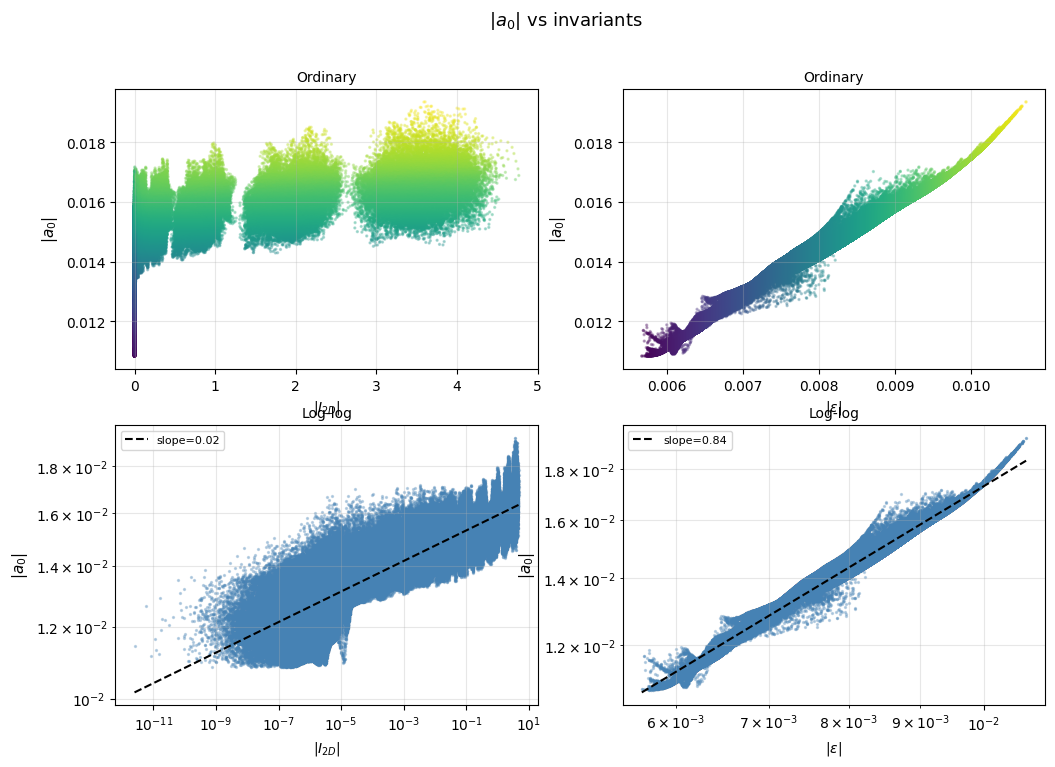

a_1 slopes: I_2D=-0.329 eps=-13.586


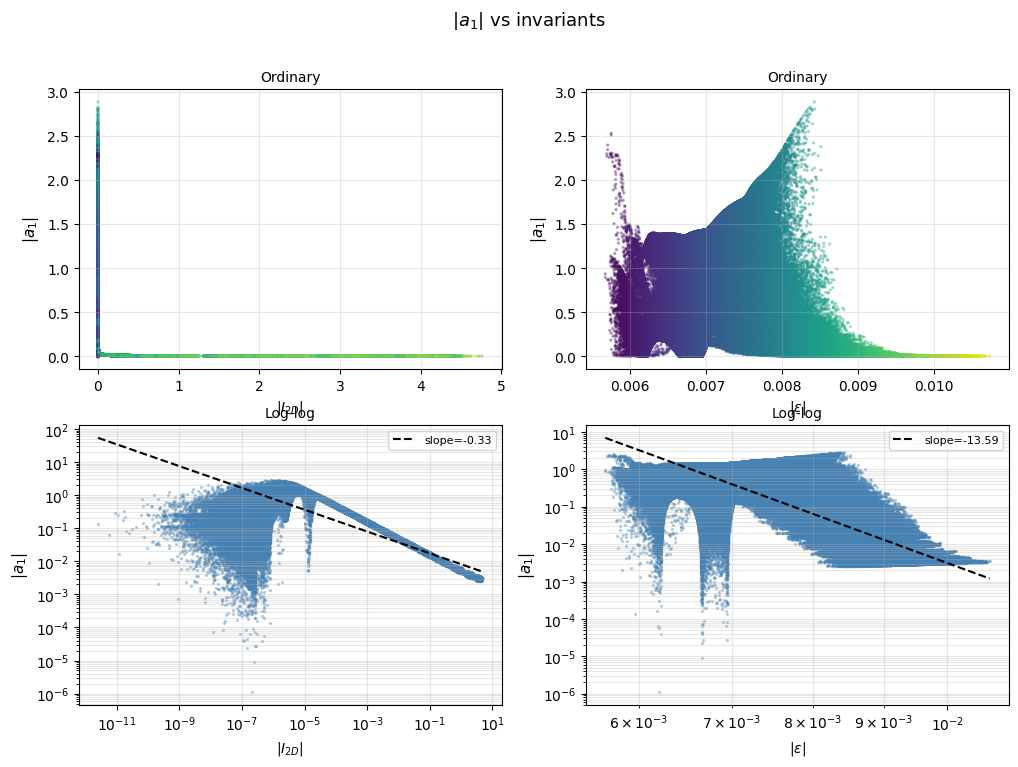

a_2 slopes: I_2D=-0.210 eps=-9.010


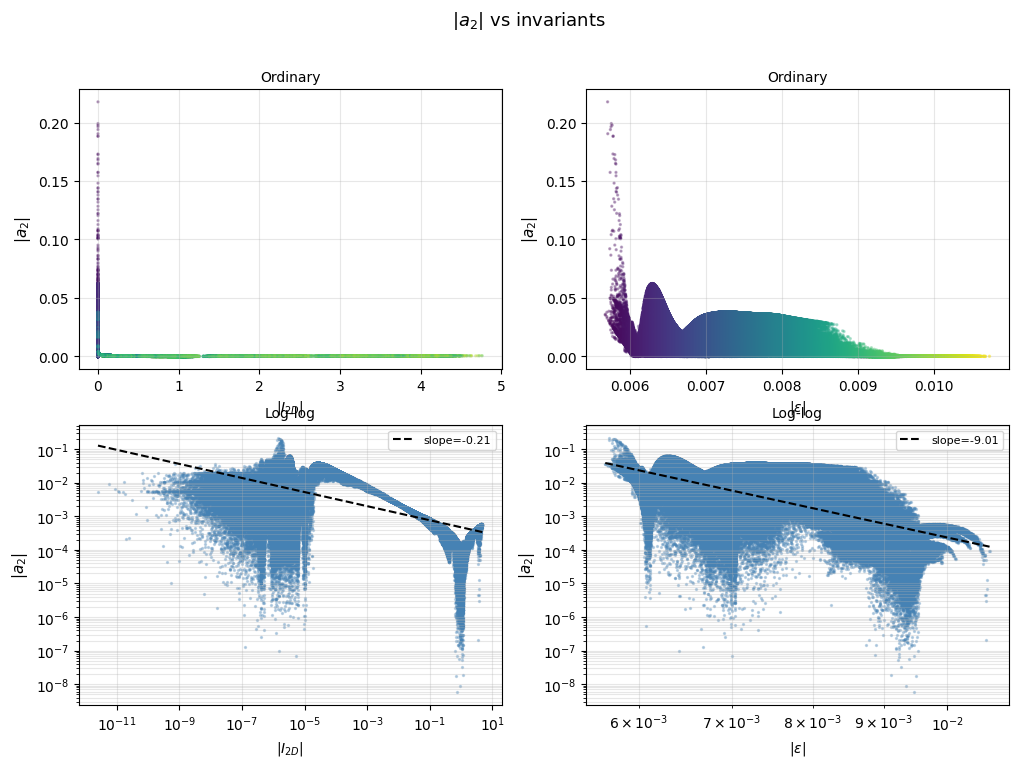

Done.


In [4]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import binned_statistic

ck      = torch.load('2D_sigma_ymasked.pt', weights_only=False)
coeffs  = ck['coeffs']
x_a_raw = ck['x_a_raw']

N  = coeffs.shape[0]
a0, a1, a2 = coeffs[:,0], coeffs[:,1], coeffs[:,2]
I2_D, eps   = x_a_raw[:,0], x_a_raw[:,1]

def plot_coeff(coeff, coeff_name, x_list, x_names, n_bins=60):
    ncols = len(x_list)
    fig, axes = plt.subplots(2, ncols, figsize=(6*ncols, 8))

    slopes = []
    for j, (x_phys, x_name) in enumerate(zip(x_list, x_names)):
        # always work with absolute values for consistency
        xabs = np.abs(x_phys)
        cabs = np.abs(coeff)

        # ── ROW 0: linear axes, |x| vs |coeff| ─────────────────────────────
        ax = axes[0, j]
        ax.scatter(xabs, cabs, s=2, alpha=0.3, c=eps, rasterized=True)
        ax.set_xlabel(f'|{x_name}|', fontsize=10)
        ax.set_ylabel(f'$|{coeff_name}|$', fontsize=11)
        ax.set_title('Ordinary', fontsize=10)
        ax.grid(True, alpha=0.3)

        # ── ROW 1: log-log axes, same |x| vs |coeff| ───────────────────────
        ax = axes[1, j]
        pos = (xabs > 0) & (cabs > 0)
        xp, cp = xabs[pos], cabs[pos]
        ax.scatter(xp, cp, s=2, alpha=0.3, color='steelblue', rasterized=True)

        # power-law slope
        lx, ly = np.log10(xp), np.log10(cp)
        fin = np.isfinite(lx) & np.isfinite(ly)
        slope = np.nan
        if fin.sum() > 2:
            slope, intercept = np.polyfit(lx[fin], ly[fin], 1)
            xl = np.linspace(lx[fin].min(), lx[fin].max(), 200)
            ax.plot(10**xl, 10**(slope*xl+intercept), 'k--', lw=1.5,
                    label=f'slope={slope:.2f}')
        slopes.append(slope)

        ax.set_xscale('log'); ax.set_yscale('log')
        ax.set_xlabel(f'|{x_name}|', fontsize=10)
        ax.set_ylabel(f'$|{coeff_name}|$', fontsize=11)
        ax.set_title('Log-log', fontsize=10)
        ax.grid(True, alpha=0.3, which='both')
        ax.legend(fontsize=8)

    plt.suptitle(f'$|{coeff_name}|$ vs invariants', fontsize=13)
    return fig, slopes

for coeff, name in zip([a0,a1,a2], ['a_0','a_1','a_2']):
    _, slopes = plot_coeff(coeff, name, [I2_D,eps], [r'$I_{2D}$',r'$\epsilon$'])
    print(f"{name} slopes: I_2D={slopes[0]:.3f} eps={slopes[1]:.3f}")
    plt.show()

print("Done.")

stress = f(A, A^2)

In [ ]:
"""
Granular Constitutive TBNN — A only
sigma* = a1*I + a2*A + a3*A²   (sigma* = sigma * dp/kn)
scalar invariants: I1=tr(A), I2=0.5*(I1²-tr(A²))
"""

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
import numpy as np

SYM_IJ = [(0,0), (1,1), (0,1), (0,2), (1,2)]  # zz from tracelessness


# =============================================================================
# DATA PROCESSOR
# =============================================================================

class GranularDataProcessor:

    def __init__(self):
        self._x_mean    = None
        self._x_std     = None
        self._s_var     = None
        self._s_clip_lo = None
        self._s_clip_hi = None

    def calc_scalar_basis(self, A, phi, epsilon, is_train=True):
        """
        3 scalar invariants of A, z-scored on training set.
        Returns (x_phys [N,3], x_scaled [N,3])
        """
        # I1 = np.einsum('nii->n', A)                              # tr(A)
        I2 = 0.5 * ((np.einsum('nii->n', A))**2 - np.einsum('nij,nij->n', A, A))      # 0.5*(I1²-tr(A²))
        I3 = np.linalg.det(A)                                         # det(A)
        x  = np.stack([I2, I3, phi, epsilon], axis=1)                          # [N,4]
        x  = np.nan_to_num(x, nan=0.0, posinf=0.0, neginf=0.0)

        if is_train:
            self._x_mean = x.mean(axis=0)
            self._x_std  = x.std(axis=0).clip(1e-8)
        if self._x_mean is None:
            raise RuntimeError("Call with is_train=True first.")

        return x, (x - self._x_mean) / self._x_std

    def calc_tensor_basis(self, A):
        """
        Returns tb [N, 3, 3, 3]: [I, A, A²]
        All 3 bases passed to TBNN (a1*I + a2*A + a3*A²).
        """
        N  = A.shape[0]
        I_ = np.eye(3)[None].repeat(N, axis=0)
        A2 = np.einsum('nij,njk->nik', A, A)
        return np.stack([I_, A, A2], axis=1)                     # [N, 3, 3, 3]

    def calc_output(self, sigma, is_train=True, clip_percentile=99.5):
        """
        Non-dimensionalise: sigma* = sigma * dp/kn
        Returns s5 [N,5]: 5 independent components of sigma*
        """
        kn = 1e5
        dp = 0.01
        s  = sigma * (dp / kn)                                   # [N,3,3]

        s5 = np.stack([s[:, i, j] for i, j in SYM_IJ], axis=1) # [N,5]
        s5 = np.nan_to_num(s5, nan=0.0, posinf=0.0, neginf=0.0)

        if is_train:
            self._s_clip_lo = np.percentile(s5, 100 - clip_percentile, axis=0)
            self._s_clip_hi = np.percentile(s5, clip_percentile,       axis=0)
        s5 = np.clip(s5, self._s_clip_lo, self._s_clip_hi)

        if is_train:
            self._s_var = s5.var(axis=0).clip(1e-8)
            for k, (i, j) in enumerate(SYM_IJ):
                print(f"  sigma*[{i},{j}]: mean={s5[:,k].mean():+.5f}  "
                      f"std={np.sqrt(self._s_var[k]):.5f}")

        return s5                                                 # [N,5]


# =============================================================================
# NETWORK STRUCTURE
# =============================================================================

class NetworkStructure:
    def __init__(self):
        self.num_layers       = 3
        self.num_nodes        = 64
        self.max_epochs       = 3000
        self.min_epochs       = 500
        self.interval         = 100
        self.average_interval = 4
        self.learning_rate    = 1e-3
        self.batch_size       = 512
        self.split_fraction   = 0.8
        self.seed             = 42
        self.lambda_coeff     = 0.01
        self.ramp_epochs      = 300

    def set_num_layers(self, n): self.num_layers = n
    def set_num_nodes(self,  n): self.num_nodes  = n
    def set_max_epochs(self, n): self.max_epochs = n
    def set_min_epochs(self, n): self.min_epochs = n


# =============================================================================
# MLP builder
# =============================================================================

def _build_mlp(n_in, n_out, num_layers, num_nodes):
    layers, d = [], n_in
    for _ in range(num_layers):
        layers += [nn.Linear(d, num_nodes), nn.LayerNorm(num_nodes), nn.GELU()]
        d = num_nodes
    layers.append(nn.Linear(d, n_out))
    nn.init.xavier_uniform_(layers[-1].weight, gain=0.05)
    nn.init.zeros_(layers[-1].bias)
    return nn.Sequential(*layers)


# =============================================================================
# GRANULAR TBNN
# =============================================================================

class GranularTBNN(nn.Module):
    """
    sigma* = a1*I + a2*A + a3*A²
    coeff_mlp: [N, n_inv] → [a1, a2, a3]   [N, 3]
    """
    def __init__(self, n_inv, n_basis, structure):
        super().__init__()
        self.n_basis   = n_basis
        self.coeff_mlp = _build_mlp(n_inv, n_basis, structure.num_layers, structure.num_nodes)

    def forward(self, x, tb):
        """
        x  [N, n_inv]
        tb [N, n_basis, 3, 3]   (I, A, A²)
        Returns: sigma_pred [N,3,3], coeffs [N,n_basis]
        """
        coeffs     = self.coeff_mlp(x)                               # [N, 3]
        sigma_pred = torch.einsum('nb,nbij->nij', coeffs, tb)        # [N, 3, 3]
        return sigma_pred, coeffs


# =============================================================================
# PHYSICS LOSS  (coefficient regularisation only)
# =============================================================================

class GranularPhysicsLoss(nn.Module):
    def __init__(self, struct):
        super().__init__()
        self.lam_coeff = struct.lambda_coeff

    def forward(self, coeffs):
        return {'coeff_loss': self.lam_coeff * (coeffs ** 2).mean()}


# =============================================================================
# TRAINER
# =============================================================================

class GranularTBNNTrainer:

    def __init__(self, model, processor, structure,
                 device='cuda' if torch.cuda.is_available() else 'cpu'):
        self.model     = model.to(device)
        self.processor = processor
        self.structure = structure
        self.device    = device
        self.phys_loss = GranularPhysicsLoss(structure).to(device)
        self.history   = {k: [] for k in ['total', 'data_s', 'coeff_loss', 'val_total']}

    def _make_loader(self, *arrays, shuffle=True):
        tensors = [torch.from_numpy(np.ascontiguousarray(a)).float() for a in arrays]
        return DataLoader(TensorDataset(*tensors),
                          batch_size=self.structure.batch_size,
                          shuffle=shuffle, num_workers=0, pin_memory=False)

    @staticmethod
    def _huber_scaled(pred, true, var, delta=1.0):
        std = torch.sqrt(var)
        err = (pred - true) / std[None, :]
        return F.huber_loss(err, torch.zeros_like(err), delta=delta, reduction='mean')

    def fit(self, x, tb, s5_true, print_every=100):
        """
        x       [N, 2]     z-scored scalar invariants
        tb      [N, 3, 3, 3]  tensor basis (I, A, A²)
        s5_true [N, 5]     non-dim stress components
        """
        struct  = self.structure
        N       = x.shape[0]
        n_basis = tb.shape[1]

        rng     = np.random.default_rng(struct.seed)
        idx     = rng.permutation(N)
        N_train = int(N * struct.split_fraction)
        tr, va  = idx[:N_train], idx[N_train:]

        tb_flat = tb.reshape(N, n_basis * 9)

        tr_loader = self._make_loader(x[tr], tb_flat[tr], s5_true[tr], shuffle=True)
        va_loader = self._make_loader(x[va], tb_flat[va], s5_true[va], shuffle=False)

        opt      = torch.optim.Adam(self.model.parameters(), lr=struct.learning_rate)
        lr_sched = torch.optim.lr_scheduler.ReduceLROnPlateau(
            opt, mode='min', factor=0.5, patience=5, min_lr=1e-6)

        s_var = torch.tensor(self.processor._s_var, dtype=torch.float32, device=self.device)

        val_window = []

        for epoch in range(struct.max_epochs):
            ep_loss   = {k: 0.0 for k in self.history if k != 'val_total'}
            n_batches = 0
            self.model.train()

            for batch in tr_loader:
                xb, tbb, sb = [t.to(self.device) for t in batch]
                tbb = tbb.view(-1, n_basis, 3, 3)

                sigma_pred, coeffs = self.model(xb, tbb)
                sigma_pred_5 = torch.stack(
                    [sigma_pred[:, i, j] for i, j in SYM_IJ], dim=1)  # [B,5]

                loss_s = self._huber_scaled(sigma_pred_5, sb, s_var)
                phys   = self.phys_loss(coeffs)
                total  = loss_s + sum(phys.values())

                opt.zero_grad()
                total.backward()

                grad_ok = all(
                    p.grad is not None and torch.isfinite(p.grad).all()
                    for p in self.model.parameters() if p.requires_grad)
                if not grad_ok:
                    opt.zero_grad()
                    print(f"  [epoch {epoch+1}] nan grad — batch skipped")
                    continue

                torch.nn.utils.clip_grad_norm_(self.model.parameters(), 1.0)
                opt.step()

                ep_loss['total']      += total.item()
                ep_loss['data_s']     += loss_s.item()
                ep_loss['coeff_loss'] += phys['coeff_loss'].item()
                n_batches += 1

            if n_batches == 0:
                print(f"Epoch {epoch+1}: ALL batches had nan — stopping.")
                break

            for k in ep_loss:
                self.history[k].append(ep_loss[k] / n_batches)

            if (epoch + 1) % struct.interval == 0:
                vl = self._eval_loss(va_loader, n_basis, s_var)
                val_window.append(vl)
                self.history['val_total'].append(vl)
                lr_sched.step(vl)

                if (epoch >= struct.min_epochs
                        and len(val_window) >= struct.average_interval * 2):
                    recent = np.mean(val_window[-struct.average_interval:])
                    older  = np.mean(val_window[-(struct.average_interval*2):-struct.average_interval])
                    if older > 1e-6 and (older - recent) / older < 1e-3:
                        print(f"Early stopping at epoch {epoch+1}.")
                        break

            if (epoch + 1) % print_every == 0:
                print(f"Epoch {epoch+1:5d} | "
                      f"total={self.history['total'][-1]:.4f} | "
                      f"s={self.history['data_s'][-1]:.4f} | "
                      f"lr={opt.param_groups[0]['lr']:.2e}")

    @torch.no_grad()
    def _eval_loss(self, loader, n_basis, s_var):
        self.model.eval()
        total, n = 0.0, 0
        for xb, tbb, sb in loader:
            xb, tbb, sb = xb.to(self.device), tbb.to(self.device), sb.to(self.device)
            tbb = tbb.view(-1, n_basis, 3, 3)
            sigma_pred, _ = self.model(xb, tbb)
            sigma_pred_5  = torch.stack(
                [sigma_pred[:, i, j] for i, j in SYM_IJ], dim=1)
            total += self._huber_scaled(sigma_pred_5, sb, s_var).item()
            n += 1
        self.model.train()
        return total / max(n, 1)

    @torch.no_grad()
    def predict(self, x, tb):
        self.model.eval()
        n_basis = tb.shape[1]
        xt  = torch.from_numpy(np.ascontiguousarray(x)).float().to(self.device)
        tbt = torch.from_numpy(
            np.ascontiguousarray(tb.reshape(len(x), n_basis * 9))).float().to(self.device)
        tbt = tbt.view(-1, n_basis, 3, 3)
        sigma_pred, coeffs = self.model(xt, tbt)
        s5 = torch.stack([sigma_pred[:, i, j] for i, j in SYM_IJ], dim=1)
        self.model.train()
        return s5.cpu().numpy(), sigma_pred.cpu().numpy(), coeffs.cpu().numpy()

    @staticmethod
    def rmse(y_true, y_pred):
        return float(np.sqrt(np.mean((y_true - y_pred) ** 2)))


# =============================================================================
# MAIN
# =============================================================================

def main():
    torch.manual_seed(42)
    np.random.seed(42)

    structure = NetworkStructure()
    structure.set_num_layers(3)
    structure.set_num_nodes(64)
    structure.set_max_epochs(3000)
    structure.set_min_epochs(500)

    print("Loading data...")
    sigma_raw = torch.load(r"D:\ml_granular\Sparse Modeling\DAY-TAH\CG_stress_Tensor_vf601vt085.pt", weights_only=False).numpy()
    A_raw     = torch.load(r"D:\ml_granular\Sparse Modeling\DAY-TAH\cg_fabric--601_085.pt",           weights_only=False).numpy()
    epsilon_raw = torch.load(r"D:\ml_granular\Sparse Modeling\DAY-TAH\cg_strains_601_085.pt", weights_only=False).numpy()
    phi_raw = torch.load(r"D:\ml_granular\Sparse Modeling\DAY-TAH\phi_vf601vt085.pt", weights_only=False).squeeze(-1).numpy()
    print(f"  Stress : {sigma_raw.shape}")
    print(f"  Fabric Anistropy tensor: {A_raw.shape}")
    print(f"  Strain(epsilon): {epsilon_raw.shape}")
    print(f"  solid vol. frac: {phi_raw.shape}")

    T, Gx, Gy, Gz = epsilon_raw.shape   # adjust if needed
    sigma_raw = sigma_raw.reshape(T, Gx, Gy, Gz, 3, 3)
    A_raw     = A_raw.reshape(T, Gx, Gy, Gz, 3, 3)
    phi_raw   = phi_raw.reshape(T, Gx, Gy, Gz)  # [T, Gx, Gy, Gz]

    # time trim + wall exclusion
    sigma_raw = sigma_raw[38:, :, 5:35, :, :, :]
    A_raw     = A_raw    [38:, :, 5:35, :, :, :]
    epsilon_raw = epsilon_raw[38:, :, 5:35, :]
    phi_raw = phi_raw[38:, :, 5:35, :]

    T2, Gx2, Gy2, Gz2 = A_raw.shape[:4]
    N = T2 * Gx2 * Gy2 * Gz2

    sigma = sigma_raw.reshape(N, 3, 3)
    A     = A_raw.reshape(N, 3, 3)
    epsilon     = epsilon_raw.reshape(N)
    phi = phi_raw.reshape(N)
    print(f"Total sample points: {N:,}")
    print("\n=============================================== ")
    print("\nComputing basis functions...")
    print("\n=============================================== ")
    processor   = GranularDataProcessor()
    x_phys, x   = processor.calc_scalar_basis(A, phi, epsilon, is_train=True)    # [N,4]
    tb           = processor.calc_tensor_basis(A)                   # [N,3,3,3]
    s5_true      = processor.calc_output(sigma, is_train=True)      # [N,5]

    print(f"\n  x       : {x.shape}   (I2 I3 phi epsilon)")
    print(f"  tb      : {tb.shape}   (I, A, A²)")
    print(f"  s5_true : {s5_true.shape}")

    n_inv, n_basis = x.shape[1], tb.shape[1]   # 4, 3
    model = GranularTBNN(n_inv, n_basis, structure)
    print(f"\nModel params: {sum(p.numel() for p in model.parameters()):,}")

    print("\nTraining...")
    trainer = GranularTBNNTrainer(model, processor, structure)
    trainer.fit(x, tb, s5_true, print_every=200)

    print("\nEvaluating on full dataset...")
    s5_pred, sigma_pred, coeffs = trainer.predict(x, tb)

    for k, (i, j) in enumerate(SYM_IJ):
        r = trainer.rmse(s5_true[:, k], s5_pred[:, k])
        print(f"RMSE sigma*[{i},{j}]: {r:.6f}  (std={np.sqrt(processor._s_var[k]):.6f})")

    print("\nMean basis coefficients:")
    for i, name in enumerate(['a1 (I)', 'a2 (A)', 'a3 (A²)']):
        print(f"  {name}: μ={coeffs[:,i].mean():+.4f}  σ={coeffs[:,i].std():.4f}")

    torch.save({
        'model_state': model.state_dict(),
        'n_inv':       n_inv,
        'n_basis':     n_basis,
        'x_mean':      processor._x_mean,
        'x_std':       processor._x_std,
        's_var':       processor._s_var,
        's_clip_lo':   processor._s_clip_lo,
        's_clip_hi':   processor._s_clip_hi,
        'coeffs':      coeffs,
        'x_phys':      x_phys,
        'x_scaled':    x,
        's5_pred':     s5_pred,
        's5_true':     s5_true,
        'grid_shape':  (T2, Gx2, Gy2, Gz2),
    }, 'granular_tbnn_A_phi.pt')
    print("\nSaved → granular_tbnn_A_phi.pt")

if __name__ == '__main__':
    main()

Loading data...
  Stress : (86, 19000, 3, 3)
  Fabric Anistropy tensor: (86, 50, 38, 10, 3, 3)
  Strain(epsilon): (86, 50, 38, 10)
  solid vol. frac: (86, 50, 38, 10)
Total sample points: 720,000


Computing basis functions...

  sigma*[0,0]: mean=-0.01167  std=0.00254
  sigma*[1,1]: mean=-0.01531  std=0.00113
  sigma*[0,1]: mean=+0.00491  std=0.00046
  sigma*[0,2]: mean=+0.00003  std=0.00021
  sigma*[1,2]: mean=-0.00003  std=0.00027

  x       : (720000, 4)   (I2 I3 phi epsilon)
  tb      : (720000, 3, 3, 3)   (I, A, A²)
  s5_true : (720000, 5)

Model params: 9,219

Training...
Epoch   200 | total=0.3917 | s=0.3909 | lr=1.00e-03
Epoch   400 | total=0.3914 | s=0.3905 | lr=1.00e-03
Epoch   600 | total=0.3891 | s=0.3881 | lr=1.00e-03
Epoch   800 | total=0.3866 | s=0.3856 | lr=1.00e-03
Epoch  1000 | total=0.3873 | s=0.3862 | lr=1.00e-03
Early stopping at epoch 1200.

Evaluating on full dataset...
RMSE sigma*[0,0]: 0.001423  (std=0.002540)
RMSE sigma*[1,1]: 0.000538  (std=0.001135)
RMSE si

stress = f(A, A^2, D, D^2)

In [13]:
"""
Granular Constitutive TBNN — A and D 
sigma* = a1*I + a2*A + a3*A^2 + a4*D + a5*D^2   (sigma* = sigma * dp/kn)
scalar invariants: I1=tr(A), I2=0.5*(I1²-tr(A²))
"""

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
import numpy as np

SYM_IJ = [(0,0), (1,1), (0,1), (0,2), (1,2)]  # zz from tracelessness


# =============================================================================
# DATA PROCESSOR
# =============================================================================

class GranularDataProcessor:

    def __init__(self):
        self._x_mean    = None
        self._x_std     = None
        self._s_var     = None
        self._s_clip_lo = None
        self._s_clip_hi = None

    def calc_scalar_basis(self, A, D, epsilon, is_train=True):
        """
        Flow state parameters, the scalar invariants which will be fit into the coefficients of the tensor basis equation
        """
        # Fabric tensor invariants (unnormalized — A is dimensionless)
        # I1_A = np.einsum('nii->n', A)
        I2_A = 0.5 * ((np.einsum('nii->n', A))**2 - np.einsum('nij,nij->n', A, A))
        I3_A = np.linalg.det(A)

        # Deformation rate tensor invariants
        I1_D  = np.einsum('nii->n', D)
        I2_D  = 0.5 * (I1_D**2 - np.einsum('nij,nij->n', D, D))

        trDhA = np.einsum('nii->n', np.einsum('nij,njk->nik', D, A))
# =================================================================================================# 
        x = np.stack([I1_D, I2_D, trDhA, epsilon], axis=1) # 4 invariants
# =================================================================================================# 
        x = np.nan_to_num(x, nan=0.0, posinf=0.0, neginf=0.0)

        if is_train:
            self._x_mean = x.mean(axis=0)
            self._x_std  = x.std(axis=0).clip(1e-8)
        if self._x_mean is None:
            raise RuntimeError("Call with is_train=True first.")
        return x, (x - self._x_mean) / self._x_std               # [N,6], [N,6]

    def calc_tensor_basis(self, A, D):
        """
        Returns tb [N, 6, 3, 3]: [I, A, A², D̂, D̂², {AD+DA}/2]
        D normalized per-sample by γ̇ = epsilon.
        """
        N     = A.shape[0]
        I_    = np.eye(3)[None].repeat(N, axis=0)
        A2    = np.einsum('nij,njk->nik', A, A)
        gamma = 0.2125                             
        D_hat = D / gamma                    # [N,3,3]
        D2_hat = np.einsum('nij,njk->nik', D_hat, D_hat)         # D̂²
        DA    = np.einsum('nij,njk->nik', D_hat, A)
        AD    = np.einsum('nij,njk->nik', A, D_hat)
        T5    = 0.5 * (DA + AD)

        # Upto all second order effects have been captured.
        return np.stack([I_, A, A2, D_hat, D2_hat, T5], axis=1)      # [N, 6, 3, 3]
    

    def calc_output(self, sigma, is_train=True, clip_percentile=99.5):
        kn = 1e5
        dp = 0.01
        s  = sigma * (dp / kn)
        s5 = np.stack([s[:, i, j] for i, j in SYM_IJ], axis=1)
        s5 = np.nan_to_num(s5, nan=0.0, posinf=0.0, neginf=0.0)
        if is_train:
            self._s_clip_lo = np.percentile(s5, 100 - clip_percentile, axis=0)
            self._s_clip_hi = np.percentile(s5, clip_percentile,       axis=0)
        s5 = np.clip(s5, self._s_clip_lo, self._s_clip_hi)
        if is_train:
            self._s_var = s5.var(axis=0).clip(1e-8)
            for k, (i, j) in enumerate(SYM_IJ):
                print(f"  sigma*[{i},{j}]: mean={s5[:,k].mean():+.5f}  "
                      f"std={np.sqrt(self._s_var[k]):.5f}")
        return s5

# =============================================================================
# NETWORK STRUCTURE
# =============================================================================

class NetworkStructure:
    def __init__(self):
        self.num_layers       = 3
        self.num_nodes        = 64
        self.max_epochs       = 3000
        self.min_epochs       = 500
        self.interval         = 100
        self.average_interval = 4
        self.learning_rate    = 1e-3
        self.batch_size       = 512
        self.split_fraction   = 0.8
        self.seed             = 42
        self.lambda_coeff     = 0.01
        self.ramp_epochs      = 300

    def set_num_layers(self, n): self.num_layers = n
    def set_num_nodes(self,  n): self.num_nodes  = n
    def set_max_epochs(self, n): self.max_epochs = n
    def set_min_epochs(self, n): self.min_epochs = n


# =============================================================================
# MLP builder
# =============================================================================

def _build_mlp(n_in, n_out, num_layers, num_nodes):
    layers, d = [], n_in
    for _ in range(num_layers):
        layers += [nn.Linear(d, num_nodes), nn.LayerNorm(num_nodes), nn.GELU()]
        d = num_nodes
    layers.append(nn.Linear(d, n_out))
    nn.init.xavier_uniform_(layers[-1].weight, gain=0.05)
    nn.init.zeros_(layers[-1].bias)
    return nn.Sequential(*layers)


# =============================================================================
# GRANULAR TBNN
# =============================================================================

class GranularTBNN(nn.Module):
    """
    sigma* = a1*I + a2*A + a3*A² + a4*D + a5*D² + a6*AD
    coeff_mlp: [N, n_inv] → [a1, a2, a3, a4, a5, a6]   [N, 6]
    """
    def __init__(self, n_inv, n_basis, structure):
        super().__init__()
        self.n_basis   = n_basis
        self.coeff_mlp = _build_mlp(n_inv, n_basis, structure.num_layers, structure.num_nodes)

    def forward(self, x, tb):
        """
        x  [N, n_inv]
        tb [N, n_basis, 3, 3]   (I, A, A^2, D, D^2, AD)
        Returns: sigma_pred [N,3,3], coeffs [N,n_basis]
        """
        coeffs     = self.coeff_mlp(x)                               # [N, 6]
        sigma_pred = torch.einsum('nb,nbij->nij', coeffs, tb)        # [N, 3, 3]
        return sigma_pred, coeffs


# =============================================================================
# PHYSICS LOSS  (coefficient regularisation only)
# =============================================================================

class GranularPhysicsLoss(nn.Module):
    def __init__(self, struct):
        super().__init__()
        self.lam_coeff = struct.lambda_coeff

    def forward(self, coeffs):
        return {'coeff_loss': self.lam_coeff * (coeffs ** 2).mean()}


# =============================================================================
# TRAINER
# =============================================================================

class GranularTBNNTrainer:

    def __init__(self, model, processor, structure,
                 device='cuda' if torch.cuda.is_available() else 'cpu'):
        self.model     = model.to(device)
        self.processor = processor
        self.structure = structure
        self.device    = device
        self.phys_loss = GranularPhysicsLoss(structure).to(device)
        self.history   = {k: [] for k in ['total', 'data_s', 'coeff_loss', 'val_total']}

    def _make_loader(self, *arrays, shuffle=True):
        tensors = [torch.from_numpy(np.ascontiguousarray(a)).float() for a in arrays]
        return DataLoader(TensorDataset(*tensors),
                          batch_size=self.structure.batch_size,
                          shuffle=shuffle, num_workers=0, pin_memory=False)

    @staticmethod
    def _huber_scaled(pred, true, var, delta=1.0):
        std = torch.sqrt(var)
        err = (pred - true) / std[None, :]
        return F.huber_loss(err, torch.zeros_like(err), delta=delta, reduction='mean')

    def fit(self, x, tb, s5_true, print_every=100):
        """
        x       [N, 4]     z-scored scalar invariants
        tb      [N, 6, 3, 3]  tensor basis (I, A, A^2, D, D^2, AD)
        s5_true [N, 5]     non-dim stress components
        """
        struct  = self.structure
        N       = x.shape[0]
        n_basis = tb.shape[1]

        rng     = np.random.default_rng(struct.seed)
        idx     = rng.permutation(N)
        N_train = int(N * struct.split_fraction)
        tr, va  = idx[:N_train], idx[N_train:]

        tb_flat = tb.reshape(N, n_basis * 9)

        tr_loader = self._make_loader(x[tr], tb_flat[tr], s5_true[tr], shuffle=True)
        va_loader = self._make_loader(x[va], tb_flat[va], s5_true[va], shuffle=False)

        opt      = torch.optim.Adam(self.model.parameters(), lr=struct.learning_rate)
        lr_sched = torch.optim.lr_scheduler.ReduceLROnPlateau(
            opt, mode='min', factor=0.5, patience=5, min_lr=1e-6)

        s_var = torch.tensor(self.processor._s_var, dtype=torch.float32, device=self.device)

        val_window = []

        for epoch in range(struct.max_epochs):
            ep_loss   = {k: 0.0 for k in self.history if k != 'val_total'}
            n_batches = 0
            self.model.train()

            for batch in tr_loader:
                xb, tbb, sb = [t.to(self.device) for t in batch]
                tbb = tbb.view(-1, n_basis, 3, 3)

                sigma_pred, coeffs = self.model(xb, tbb)
                sigma_pred_5 = torch.stack(
                    [sigma_pred[:, i, j] for i, j in SYM_IJ], dim=1)  # [B,5]

                loss_s = self._huber_scaled(sigma_pred_5, sb, s_var)
                phys   = self.phys_loss(coeffs)
                total  = loss_s + sum(phys.values())

                opt.zero_grad()
                total.backward()

                grad_ok = all(
                    p.grad is not None and torch.isfinite(p.grad).all()
                    for p in self.model.parameters() if p.requires_grad)
                if not grad_ok:
                    opt.zero_grad()
                    print(f"  [epoch {epoch+1}] nan grad — batch skipped")
                    continue

                torch.nn.utils.clip_grad_norm_(self.model.parameters(), 1.0)
                opt.step()

                ep_loss['total']      += total.item()
                ep_loss['data_s']     += loss_s.item()
                ep_loss['coeff_loss'] += phys['coeff_loss'].item()
                n_batches += 1

            if n_batches == 0:
                print(f"Epoch {epoch+1}: ALL batches had nan — stopping.")
                break

            for k in ep_loss:
                self.history[k].append(ep_loss[k] / n_batches)

            if (epoch + 1) % struct.interval == 0:
                vl = self._eval_loss(va_loader, n_basis, s_var)
                val_window.append(vl)
                self.history['val_total'].append(vl)
                lr_sched.step(vl)

                if (epoch >= struct.min_epochs
                        and len(val_window) >= struct.average_interval * 2):
                    recent = np.mean(val_window[-struct.average_interval:])
                    older  = np.mean(val_window[-(struct.average_interval*2):-struct.average_interval])
                    if older > 1e-6 and (older - recent) / older < 1e-3:
                        print(f"Early stopping at epoch {epoch+1}.")
                        break

            if (epoch + 1) % print_every == 0:
                print(f"Epoch {epoch+1:5d} | "
                      f"total={self.history['total'][-1]:.4f} | "
                      f"s={self.history['data_s'][-1]:.4f} | "
                      f"lr={opt.param_groups[0]['lr']:.2e}")

    @torch.no_grad()
    def _eval_loss(self, loader, n_basis, s_var):
        self.model.eval()
        total, n = 0.0, 0
        for xb, tbb, sb in loader:
            xb, tbb, sb = xb.to(self.device), tbb.to(self.device), sb.to(self.device)
            tbb = tbb.view(-1, n_basis, 3, 3)
            sigma_pred, _ = self.model(xb, tbb)
            sigma_pred_5  = torch.stack(
                [sigma_pred[:, i, j] for i, j in SYM_IJ], dim=1)
            total += self._huber_scaled(sigma_pred_5, sb, s_var).item()
            n += 1
        self.model.train()
        return total / max(n, 1)

    @torch.no_grad()
    def predict(self, x, tb):
        self.model.eval()
        n_basis = tb.shape[1]
        xt  = torch.from_numpy(np.ascontiguousarray(x)).float().to(self.device)
        tbt = torch.from_numpy(
            np.ascontiguousarray(tb.reshape(len(x), n_basis * 9))).float().to(self.device)
        tbt = tbt.view(-1, n_basis, 3, 3)
        sigma_pred, coeffs = self.model(xt, tbt)
        s5 = torch.stack([sigma_pred[:, i, j] for i, j in SYM_IJ], dim=1)
        self.model.train()
        return s5.cpu().numpy(), sigma_pred.cpu().numpy(), coeffs.cpu().numpy()

    @staticmethod
    def rmse(y_true, y_pred):
        return float(np.sqrt(np.mean((y_true - y_pred) ** 2)))


# =============================================================================
# MAIN
# =============================================================================

def main():
    torch.manual_seed(42)
    np.random.seed(42)

    structure = NetworkStructure()
    structure.set_num_layers(3)
    structure.set_num_nodes(64)
    structure.set_max_epochs(3000)
    structure.set_min_epochs(500)

    print("Loading data...")
    sigma_raw = torch.load(r"D:\ml_granular\Sparse Modeling\DAY-TAH\CG_stress_Tensor_vf601vt085.pt", weights_only=False).numpy()
    deformation_raw = torch.load(r"D:\ml_granular\Sparse Modeling\DAY-TAH\deformation_tensorvf601vt085.pt", weights_only=False).numpy()
    A_raw     = torch.load(r"D:\ml_granular\Sparse Modeling\DAY-TAH\cg_fabric--601_085.pt",           weights_only=False).numpy()
    epsilon_raw = torch.load(r"D:\ml_granular\Sparse Modeling\DAY-TAH\cg_strains_601_085.pt", weights_only=False).numpy()
    # phi_raw = torch.load(r"D:\ml_granular\Sparse Modeling\DAY-TAH\phi_vf601vt085.pt", weights_only=False).squeeze(-1).numpy()
    print(f"  Stress : {sigma_raw.shape}")
    print(f"  Deformation tensor: {deformation_raw.shape}")
    print(f"  Fabric Anistropy tensor: {A_raw.shape}")
    print(f"  Strain(epsilon): {epsilon_raw.shape}")
    # print(f"  solid vol. frac: {phi_raw.shape}")

    T, Gx, Gy, Gz = epsilon_raw.shape   # adjust if needed
    sigma_raw = sigma_raw.reshape(T, Gx, Gy, Gz, 3, 3)
    deformation_raw = deformation_raw.reshape(T, Gx, Gy, Gz, 3, 3)
    A_raw     = A_raw.reshape(T, Gx, Gy, Gz, 3, 3)
    # phi_raw   = phi_raw.reshape(T, Gx, Gy, Gz)  # [T, Gx, Gy, Gz]

    # time trim + wall exclusion
    time_stamp = 35
    sigma_raw = sigma_raw[time_stamp:, :, 5:35, :, :, :]
    deformation_raw = deformation_raw[time_stamp:, :, 5:35, :, :, :]
    A_raw     = A_raw    [time_stamp:, :, 5:35, :, :, :]
    epsilon_raw = epsilon_raw[time_stamp:, :, 5:35, :]
    # phi_raw = phi_raw[time_stamp:, :, 5:35, :]

    T2, Gx2, Gy2, Gz2 = A_raw.shape[:4]
    N = T2 * Gx2 * Gy2 * Gz2

    sigma = sigma_raw.reshape(N, 3, 3)
    D = deformation_raw.reshape(N, 3, 3)
    A     = A_raw.reshape(N, 3, 3)
    epsilon     = epsilon_raw.reshape(N)
    # phi = phi_raw.reshape(N)
    print(f"Total sample points: {N:,}")
    print("\n=============================================== ")
    print("\nComputing basis functions...")
    print("\n=============================================== ")
    processor   = GranularDataProcessor()
    x_phys, x   = processor.calc_scalar_basis(A, D, epsilon, is_train=True)    # [N,6]
    tb           = processor.calc_tensor_basis(A, D)                   # [N,6,3,3]
    s5_true      = processor.calc_output(sigma, is_train=True)      # [N,5]

    print(f"\n  x       : {x.shape}   (I1(D), I2(D), tr(AD), epsilon)")
    print(f"  tb      : {tb.shape}   (I, A, A^2, D, D^2, AD)")
    print(f"  s5_true : {s5_true.shape}")

    n_inv, n_basis = x.shape[1], tb.shape[1]   # 6, 6
    model = GranularTBNN(n_inv, n_basis, structure)
    print(f"\nModel params: {sum(p.numel() for p in model.parameters()):,}")

    print("\nTraining...")
    trainer = GranularTBNNTrainer(model, processor, structure)
    trainer.fit(x, tb, s5_true, print_every=200)

    print("\nEvaluating on full dataset...")
    s5_pred, sigma_pred, coeffs = trainer.predict(x, tb)

    for k, (i, j) in enumerate(SYM_IJ):
        r = trainer.rmse(s5_true[:, k], s5_pred[:, k])
        print(f"RMSE sigma*[{i},{j}]: {r:.6f}  (std={np.sqrt(processor._s_var[k]):.6f})")

    print("\nMean basis coefficients:")
    for i, name in enumerate(['a1 (I)', 'a2 (A)', 'a3 (A²)', 'a4 (D)', 'a5 (D²)', 'a6 (DA)']):
        print(f"  {name}: μ={coeffs[:,i].mean():+.4f}  σ={coeffs[:,i].std():.4f}") 

    torch.save({
        'model_state': model.state_dict(),
        'n_inv':       n_inv,
        'n_basis':     n_basis,
        'x_mean':      processor._x_mean,
        'x_std':       processor._x_std,
        's_var':       processor._s_var,
        's_clip_lo':   processor._s_clip_lo,
        's_clip_hi':   processor._s_clip_hi,
        'coeffs':      coeffs,
        'x_phys':      x_phys,
        'x_scaled':    x,
        's5_pred':     s5_pred,
        's5_true':     s5_true,
        'grid_shape':  (T2, Gx2, Gy2, Gz2),
    }, 'granular_tbnn_AD.pt')
    print("\nSaved → granular_tbnn_AD.pt")

if __name__ == '__main__':
    main()

Loading data...
  Stress : (86, 19000, 3, 3)
  Deformation tensor: (86, 50, 38, 10, 3, 3)
  Fabric Anistropy tensor: (86, 50, 38, 10, 3, 3)
  Strain(epsilon): (86, 50, 38, 10)
Total sample points: 765,000


Computing basis functions...

  sigma*[0,0]: mean=-0.01164  std=0.00254
  sigma*[1,1]: mean=-0.01528  std=0.00114
  sigma*[0,1]: mean=+0.00489  std=0.00046
  sigma*[0,2]: mean=+0.00003  std=0.00021
  sigma*[1,2]: mean=-0.00003  std=0.00027

  x       : (765000, 4)   (I1(D), I2(D), tr(AD), epsilon)
  tb      : (765000, 6, 3, 3)   (I, A, A^2, D, D^2, AD)
  s5_true : (765000, 5)

Model params: 9,414

Training...
Epoch   200 | total=0.3861 | s=0.3858 | lr=1.00e-03
Epoch   400 | total=0.3834 | s=0.3830 | lr=1.00e-03
Epoch   600 | total=0.3818 | s=0.3814 | lr=1.00e-03
Epoch   800 | total=0.3812 | s=0.3807 | lr=1.00e-03
Epoch  1000 | total=0.3800 | s=0.3795 | lr=1.00e-03
Epoch  1200 | total=0.3803 | s=0.3798 | lr=1.00e-03
Epoch  1400 | total=0.3798 | s=0.3793 | lr=1.00e-03
Epoch  1600 | to

In [ ]:
"""
Physically Appropriate Predictions for Low-Re Cylinder Flow (Re = 50–160)
=========================================================================

Data layout (from README):
    TensorReXXX.mat : [N_comp, N_x, N_y, N_t] = [2, 500, 500, 500]
        axis-0  N_comp = 2  : component 0 = U (x-velocity), component 1 = V (y-velocity)
        axis-1  N_x    = 500
        axis-2  N_y    = 500
        axis-3  N_t    = 500  (Δt = 1)
    X.mat, Y.mat : [N_x, N_y]  spatial mesh coordinates

Since Re = 50–160 is the LAMINAR PERIODIC regime the pipeline offers:
    Option 1 — Global scalars  : St, Cl_rms, Cd_proxy, L_r, k_max, k_wake
    Option 2 — Mean field reg. : Ū(x,y), V̄(x,y) at unseen Re

Usage:
    python cylinder_flow_analyzer.py
"""

import numpy as np
import scipy.io
import h5py
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader


# =============================================================================
# DATA LOADING
# =============================================================================

def load_mat_smart(path: str) -> np.ndarray:
    """Load a .mat file regardless of version (v5 or v7.3/HDF5)."""
    # --- try scipy first (v5 .mat) ---
    try:
        raw  = scipy.io.loadmat(path)
        keys = [k for k in raw if not k.startswith("_")]
        if keys:
            return np.array(raw[keys[0]], dtype=np.float32)
    except NotImplementedError:
        pass

    # --- fall back to h5py (v7.3 HDF5 .mat) ---
    with h5py.File(path, 'r') as f:
        keys = [k for k in f.keys() if not k.startswith('#')]
        # HDF5 stores arrays in Fortran order → transpose to C order
        arr  = f[keys[0]][()].T
    return arr.astype(np.float32)


def load_xy_grid(data_dir: str) -> tuple[np.ndarray, np.ndarray]:
    """
    Load the shared spatial mesh.

    Returns
    -------
    X : [N_x, N_y]  x-coordinates of every grid point
    Y : [N_x, N_y]  y-coordinates of every grid point
    """
    X = load_mat_smart(os.path.join(data_dir, "X.mat"))   # already [N_x, N_y]
    Y = load_mat_smart(os.path.join(data_dir, "Y.mat"))

    # Squeeze any singleton dims (some .mat exports add an extra axis)
    if X.ndim == 3:
        X = X.squeeze(0)
    if Y.ndim == 3:
        Y = Y.squeeze(0)

    print(f"  Grid loaded:  X.shape={X.shape}  Y.shape={Y.shape}")
    return X, Y


def load_single_re(data_dir: str, re: int, X: np.ndarray, Y: np.ndarray) -> dict:
    """
    Load one Reynolds-number dataset.

    The raw tensor has shape [N_comp, N_x, N_y, N_t].
    We split it into U [N_x, N_y, N_t] and V [N_x, N_y, N_t].

    Parameters
    ----------
    data_dir : directory containing TensorReXXX.mat files
    re       : Reynolds number (integer)
    X, Y     : shared [N_x, N_y] mesh (loaded once by load_xy_grid)
    """
    mat_path = os.path.join(data_dir, f"TensorRe{re:03d}.mat")
    raw      = load_mat_smart(mat_path)   # [2, N_x, N_y, N_t]

    if raw.ndim != 4 or raw.shape[0] != 2:
        raise ValueError(
            f"Expected shape [2, N_x, N_y, N_t] for Re={re}, got {raw.shape}")

    U = raw[0]   # [N_x, N_y, N_t]
    V = raw[1]   # [N_x, N_y, N_t]

    return {
        "Re": re,
        "U":  U,   # [N_x, N_y, N_t]
        "V":  V,   # [N_x, N_y, N_t]
        "X":  X,   # [N_x, N_y]  shared grid
        "Y":  Y,   # [N_x, N_y]  shared grid
    }


def load_all_re(data_dir: str, re_list: list) -> list:
    """Load all Re datasets and the shared grid."""
    X, Y     = load_xy_grid(data_dir)
    datasets = []
    for re in re_list:
        try:
            ds = load_single_re(data_dir, re, X, Y)
            print(f"  Loaded Re={re:5d}  U.shape={ds['U'].shape}")
            datasets.append(ds)
        except FileNotFoundError:
            print(f"  Skipped Re={re}  (file not found)")
    return datasets


# =============================================================================
# OPTION 1 — GLOBAL SCALAR EXTRACTION
# =============================================================================

def _wake_probe_indices(X: np.ndarray, Y: np.ndarray) -> tuple[int, int]:
    """
    Find grid indices closest to (x_cyl, y_mid) — the cylinder centre-line.

    The cylinder is assumed to sit near the left-centre of the domain.
    We use the column with the minimum x-value as x_cyl and the row
    closest to the domain's y-midpoint as cy.
    """
    x_cyl = X[:, 0].min()   # leftmost x column ≈ cylinder location
    y_mid = (Y[0, :].max() + Y[0, :].min()) / 2.0

    # Index in x closest to cylinder x-position
    cx = int(np.argmin(np.abs(X[:, 0] - x_cyl)))
    # Index in y closest to midplane
    cy = int(np.argmin(np.abs(Y[0, :] - y_mid)))
    return cx, cy


def extract_global_scalars(ds: dict,
                            D:     float = 1.0,
                            U_inf: float = 1.0,
                            dt:    float = 1.0) -> dict:
    """
    Extract non-dimensional global scalars from one Re dataset.

    Returns
    -------
    dict with keys: Re, St, Cl_rms, Cd_mean, L_r, k_max, k_wake
    """
    U, V = ds['U'], ds['V']          # each [N_x, N_y, N_t]
    X, Y = ds['X'], ds['Y']          # each [N_x, N_y]
    Re   = ds['Re']
    Nt   = U.shape[2]

    # ---- Time-mean and fluctuations ----
    U_mean = U.mean(axis=2)          # [N_x, N_y]
    V_mean = V.mean(axis=2)
    u_f    = U - U_mean[:, :, None]  # [N_x, N_y, N_t]
    v_f    = V - V_mean[:, :, None]

    # ---- Probe location ----
    cx, cy = _wake_probe_indices(X, Y)

    # ---- Strouhal number via FFT of v-fluctuation probe ----
    v_probe = v_f[cx, cy, :]         # [N_t]  at cylinder wake centreline

    if np.std(v_probe) > 1e-8:
        freqs  = np.fft.rfftfreq(Nt, d=dt)
        fft_v  = np.abs(np.fft.rfft(v_probe))
        f_shed = freqs[np.argmax(fft_v[1:]) + 1]   # skip DC
        St     = float(f_shed * D / U_inf)
    else:
        St = 0.0

    # ---- RMS lift proxy (normalised) ----
    Cl_rms = float(np.std(v_probe) / (0.5 * U_inf**2 * D))

    # ---- Mean drag proxy — momentum deficit at 75 % downstream ----
    Nx       = X.shape[0]
    x_ds_idx = min(int(0.75 * Nx), Nx - 1)
    u_ds     = U_mean[x_ds_idx, :]           # [N_y]  1-D profile at that x-slice
    y_1d     = Y[x_ds_idx, :]               # [N_y]  y-coordinates at that slice
    Cd_mean  = float(np.trapz(np.clip(U_inf - u_ds, 0, U_inf), y_1d) / (U_inf * D))

    # ---- Recirculation length — most downstream x where U_mean < 0 on centreline ----
    u_centre      = U_mean[:, cy]            # [N_x]
    recirculating = np.where(u_centre < 0)[0]
    x_cyl_val     = X[cx, cy]
    L_r = float((X[recirculating[-1], cy] - x_cyl_val) / D) if len(recirculating) else 0.0

    # ---- Coherent (periodic) turbulent kinetic energy ----
    k_field = 0.5 * (u_f.var(axis=2) + v_f.var(axis=2))   # [N_x, N_y]
    k_max   = float(k_field.max())

    # Wake region: downstream half, ±10 rows around centreline
    cy_lo = max(0, cy - 10)
    cy_hi = min(k_field.shape[1], cy + 11)
    k_wake = float(k_field[cx:, cy_lo:cy_hi].mean())

    return {
        'Re': Re, 'St': St, 'Cl_rms': Cl_rms, 'Cd_mean': Cd_mean,
        'L_r': L_r, 'k_max': k_max, 'k_wake': k_wake,
    }


def extract_all_scalars(datasets: list, D=1.0, U_inf=1.0, dt=1.0) -> np.ndarray:
    """
    Extract scalars from all Re datasets.

    Returns
    -------
    table : [n_re, 7]  columns: Re, St, Cl_rms, Cd_mean, L_r, k_max, k_wake
    """
    print("\nExtracting global scalars:")
    print(f"  {'Re':>6}  {'St':>8}  {'Cl_rms':>8}  {'Cd_mean':>8}  "
          f"{'L_r':>6}  {'k_max':>10}")
    print("  " + "-" * 62)

    rows = []
    for ds in datasets:
        s = extract_global_scalars(ds, D=D, U_inf=U_inf, dt=dt)
        rows.append([s['Re'], s['St'], s['Cl_rms'], s['Cd_mean'],
                     s['L_r'], s['k_max'], s['k_wake']])
        print(f"  {s['Re']:>6}  {s['St']:>8.4f}  {s['Cl_rms']:>8.4f}  "
              f"{s['Cd_mean']:>8.4f}  {s['L_r']:>6.3f}  {s['k_max']:>10.6f}")

    return np.array(rows, dtype=np.float32)


def plot_scalars(table: np.ndarray) -> None:
    """Plot global scalars vs Re with Williamson (1988) St reference."""
    try:
        import matplotlib.pyplot as plt
    except ImportError:
        print("matplotlib not available — skipping scalar plots")
        return

    Re_vals = table[:, 0]
    labels  = ['St', 'Cl_rms', 'Cd (proxy)', 'L_r/D', 'k_max', 'k_wake']
    cols    = [1, 2, 3, 4, 5, 6]

    fig, axes = plt.subplots(2, 3, figsize=(14, 7))
    fig.suptitle("Global scalars vs Reynolds number", fontsize=13)

    for ax, col, label in zip(axes.flat, cols, labels):
        ax.plot(Re_vals, table[:, col], 'o-', lw=1.5, ms=6)
        ax.set_xlabel('Re'); ax.set_ylabel(label); ax.set_title(label)
        ax.grid(True, alpha=0.3)

    # Williamson (1988) empirical St–Re relation
    Re_lit = np.linspace(50, 200, 100)
    St_lit = 0.198 * (1 - 19.7 / Re_lit)
    axes[0, 0].plot(Re_lit, St_lit, 'r--', lw=1, label='Williamson (1988)')
    axes[0, 0].legend(fontsize=8)

    plt.tight_layout()
    plt.savefig('global_scalars_vs_Re.png', dpi=150)
    plt.show()
    print("Saved global_scalars_vs_Re.png")


# =============================================================================
# OPTION 2 — MEAN FLOW FIELD REGRESSION
# =============================================================================

class MeanFieldRegressor(nn.Module):
    """
    Predict the time-averaged velocity field (Ū, V̄) at an unseen Re.

    Input  : [x_norm, y_norm, Re_norm, x_norm * Re_norm]   (4 features / point)
    Output : [Ū / U_inf,  V̄ / U_inf]
    """

    def __init__(self, n_hidden: int = 128, n_layers: int = 4):
        super().__init__()
        layers, d = [], 4
        for _ in range(n_layers):
            layers += [nn.Linear(d, n_hidden), nn.LayerNorm(n_hidden), nn.GELU()]
            d = n_hidden
        layers.append(nn.Linear(d, 2))
        self.net = nn.Sequential(*layers)
        nn.init.xavier_uniform_(self.net[-1].weight, gain=0.1)

    def forward(self, x):
        return self.net(x)


def build_mean_field_dataset(datasets: list,
                              U_inf:   float = 1.0,
                              Re_ref:  float = 100.0) -> tuple:
    """
    Build (features, targets) arrays for mean field regression.

    The shared X, Y grid from any dataset is used for normalisation
    (all datasets share the same mesh).

    Features : [x_norm, y_norm, Re_norm, x_norm * Re_norm]
    Targets  : [U_mean / U_inf,  V_mean / U_inf]

    Returns
    -------
    features : [N_total, 4]
    targets  : [N_total, 2]
    meta     : list of (Re, N_x, N_y) for later reconstruction
    """
    # Use the grid from the first dataset for global normalisation
    X0 = datasets[0]['X']   # [N_x, N_y]
    Y0 = datasets[0]['Y']
    x_min, x_max = float(X0.min()), float(X0.max())
    y_min, y_max = float(Y0.min()), float(Y0.max())

    all_feat, all_targ, meta = [], [], []

    for ds in datasets:
        U_mean = ds['U'].mean(axis=2)          # [N_x, N_y]
        V_mean = ds['V'].mean(axis=2)
        X, Y   = ds['X'], ds['Y']
        Re     = ds['Re']
        N_x, N_y = X.shape

        x_flat = X.reshape(-1)
        y_flat = Y.reshape(-1)

        x_norm  = (x_flat - x_min) / (x_max - x_min + 1e-8)
        y_norm  = (y_flat - y_min) / (y_max - y_min + 1e-8)
        re_norm = np.full(N_x * N_y, Re / Re_ref, dtype=np.float32)

        feat = np.stack([x_norm.astype(np.float32),
                         y_norm.astype(np.float32),
                         re_norm,
                         (x_norm * re_norm).astype(np.float32)], axis=1)
        targ = np.stack([U_mean.reshape(-1) / U_inf,
                         V_mean.reshape(-1) / U_inf], axis=1).astype(np.float32)

        all_feat.append(feat)
        all_targ.append(targ)
        meta.append((Re, N_x, N_y))

    return (np.concatenate(all_feat, axis=0),
            np.concatenate(all_targ, axis=0),
            meta)


def train_mean_field_regressor(features:   np.ndarray,
                                targets:    np.ndarray,
                                test_mask:  np.ndarray = None,
                                n_epochs:   int        = 2000,
                                lr:         float      = 1e-3,
                                batch_size: int        = 16384,
                                device:     str        = None) -> MeanFieldRegressor:
    """Train the mean-field regressor (leave-one-Re-out supported)."""
    device = device or ('cuda' if torch.cuda.is_available() else 'cpu')
    model  = MeanFieldRegressor(n_hidden=128, n_layers=4).to(device)
    opt    = torch.optim.Adam(model.parameters(), lr=lr)
    sched  = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=n_epochs)

    tr_feat = features[~test_mask] if test_mask is not None else features
    tr_targ = targets[~test_mask]  if test_mask is not None else targets

    loader = DataLoader(
        TensorDataset(torch.from_numpy(tr_feat), torch.from_numpy(tr_targ)),
        batch_size=batch_size, shuffle=True, num_workers=0)

    print(f"\nTraining mean-field regressor on {len(tr_feat):,} points "
          f"({sum(p.numel() for p in model.parameters()):,} params) ...")

    for epoch in range(n_epochs):
        model.train()
        ep_loss = 0.0
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            loss   = F.mse_loss(model(xb), yb)
            opt.zero_grad(); loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
            ep_loss += loss.item()
        sched.step()

        if (epoch + 1) % 400 == 0:
            print(f"  Epoch {epoch+1:5d} | loss={ep_loss/len(loader):.6f}"
                  f" | lr={opt.param_groups[0]['lr']:.2e}")

    return model


@torch.no_grad()
def predict_mean_field(model:   MeanFieldRegressor,
                       X:       np.ndarray,
                       Y:       np.ndarray,
                       Re_new:  float,
                       X_ref:   np.ndarray = None,
                       Y_ref:   np.ndarray = None,
                       Re_ref:  float      = 100.0,
                       U_inf:   float      = 1.0,
                       device:  str        = None) -> tuple:
    """
    Predict mean velocity field at a new Re.

    X_ref, Y_ref : the same grid used during training (for consistent normalisation).
                   If None, X and Y themselves are used.

    Returns
    -------
    U_pred : [N_x, N_y]
    V_pred : [N_x, N_y]
    """
    device  = device or ('cuda' if torch.cuda.is_available() else 'cpu')
    model   = model.to(device).eval()

    xr = X_ref if X_ref is not None else X
    yr = Y_ref if Y_ref is not None else Y
    x_min, x_max = float(xr.min()), float(xr.max())
    y_min, y_max = float(yr.min()), float(yr.max())

    N_x, N_y = X.shape
    x_flat = X.reshape(-1).astype(np.float32)
    y_flat = Y.reshape(-1).astype(np.float32)

    x_norm  = (x_flat - x_min) / (x_max - x_min + 1e-8)
    y_norm  = (y_flat - y_min) / (y_max - y_min + 1e-8)
    re_norm = np.full(N_x * N_y, Re_new / Re_ref, dtype=np.float32)

    feat   = np.stack([x_norm, y_norm, re_norm, x_norm * re_norm], axis=1)
    pred   = model(torch.from_numpy(feat).float().to(device)).cpu().numpy()

    U_pred = (pred[:, 0] * U_inf).reshape(N_x, N_y)
    V_pred = (pred[:, 1] * U_inf).reshape(N_x, N_y)
    return U_pred, V_pred


def plot_mean_field_comparison(U_true: np.ndarray, V_true: np.ndarray,
                                U_pred: np.ndarray, V_pred: np.ndarray,
                                Re: float, X: np.ndarray, Y: np.ndarray) -> None:
    """Side-by-side comparison of true vs predicted mean velocity fields."""
    try:
        import matplotlib.pyplot as plt
    except ImportError:
        print("matplotlib not available — skipping field plots")
        return

    # For imshow we need the transposed field so x→horizontal, y→vertical
    fields = [(U_true, U_pred, 'U (streamwise)'),
              (V_true, V_pred, 'V (transverse)')]

    fig, axes = plt.subplots(2, 3, figsize=(16, 8))
    fig.suptitle(f"Mean flow field  —  Re = {Re}", fontsize=13)

    extent = [X.min(), X.max(), Y.min(), Y.max()]

    for row, (true, pred, name) in enumerate(fields):
        vmin, vmax = true.min(), true.max()
        err  = pred - true
        rmse = float(np.sqrt((err**2).mean()))

        kw = dict(origin='lower', aspect='auto', extent=extent, cmap='RdBu_r',
                  vmin=vmin, vmax=vmax)

        im0 = axes[row, 0].imshow(true.T, **kw)
        axes[row, 0].set_title(f'True {name}')
        plt.colorbar(im0, ax=axes[row, 0])

        im1 = axes[row, 1].imshow(pred.T, **kw)
        axes[row, 1].set_title(f'Predicted {name}')
        plt.colorbar(im1, ax=axes[row, 1])

        kw_err = dict(origin='lower', aspect='auto', extent=extent, cmap='coolwarm')
        im2 = axes[row, 2].imshow(err.T, **kw_err)
        axes[row, 2].set_title(f'Error  (RMSE = {rmse:.4f})')
        plt.colorbar(im2, ax=axes[row, 2])

    plt.tight_layout()
    fname = f"mean_field_Re{int(Re)}.png"
    plt.savefig(fname, dpi=150)
    plt.show()
    print(f"Saved {fname}")


def plot_snapshot(ds: dict, t_idx: int = 0) -> None:
    """Quick sanity-check plot: one velocity snapshot (rotated 90°)."""
    try:
        import matplotlib.pyplot as plt
    except ImportError:
        return
 
    U, V = ds['U'][:, :, t_idx], ds['V'][:, :, t_idx]
    X, Y = ds['X'], ds['Y']
    extent = [X.min(), X.max(), Y.min(), Y.max()]
 
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
    fig.suptitle(f"Snapshot t={t_idx}  Re={ds['Re']}", fontsize=12)
 
    # Rotate 90° clockwise: np.rot90(arr, k=-1) or equivalently use np.rot90(arr, k=3)
    # and flip extent to match rotation
    # extent_rot = [Y.min(), Y.max(), X.min(), X.max()]  # swap x↔y after rotation
 
    im1 = ax1.imshow(U, origin='lower', aspect='auto', extent=extent, cmap='RdBu_r')
    ax1.set_title('U (x-velocity)'); ax1.set_xlabel('X'); ax1.set_ylabel('Y')
    plt.colorbar(im1, ax=ax1)
 
    im2 = ax2.imshow(V, origin='lower', aspect='auto', extent=extent, cmap='RdBu_r')
    ax2.set_title('V (y-velocity)'); ax2.set_xlabel('X'); ax2.set_ylabel('Y')
    plt.colorbar(im2, ax=ax2)
 
    plt.tight_layout()
    plt.show()
  

# =============================================================================
# FULL DRIVER
# =============================================================================

def main(data_dir: str = ".",
         re_list:  list = None,
         test_re:  int  = None,
         D:        float = 1.0,
         U_inf:    float = 1.0) -> tuple:
    """
    Run the full pipeline.

    Parameters
    ----------
    data_dir : directory with TensorReXXX.mat / X.mat / Y.mat
    re_list  : list of Re values to load
    test_re  : Re to hold out for leave-one-out evaluation
    D        : cylinder diameter (non-dim units, typically 1.0)
    U_inf    : free-stream velocity (non-dim units, typically 1.0)
    """
    if re_list is None:
        re_list = [50, 60, 85, 100, 130, 160]

    # ------------------------------------------------------------------ load
    print("=" * 60)
    print("Loading datasets")
    print("=" * 60)
    datasets = load_all_re(data_dir, re_list)
    if not datasets:
        raise RuntimeError("No datasets loaded — check data_dir and re_list.")

    Re_ref = float(re_list[0])   # reference Re for normalisation

    # Sanity-check snapshot
    plot_snapshot(datasets[0], t_idx=0)

    # ------------------------------------------------------------------ Option 1
    print("\n" + "=" * 60)
    print("OPTION 1: Global scalar extraction")
    print("=" * 60)
    scalar_table = extract_all_scalars(datasets, D=D, U_inf=U_inf, dt=1.0)
    plot_scalars(scalar_table)

    # ------------------------------------------------------------------ Option 2
    print("\n" + "=" * 60)
    print("OPTION 2: Mean flow field regression")
    print("=" * 60)
    features, targets, meta = build_mean_field_dataset(
        datasets, U_inf=U_inf, Re_ref=Re_ref)

    # Build test-point mask for the held-out Re
    test_mask = None
    if test_re is not None:
        re_vals   = [re for re, _, _ in meta]
        sizes     = [Nx * Ny for _, Nx, Ny in meta]
        offsets   = np.cumsum([0] + sizes)
        if test_re in re_vals:
            ti        = re_vals.index(test_re)
            test_mask = np.zeros(len(features), dtype=bool)
            test_mask[offsets[ti]:offsets[ti + 1]] = True
            print(f"  Hold-out Re={test_re}: "
                  f"{test_mask.sum():,} test  |  {(~test_mask).sum():,} train")
        else:
            print(f"  test_re={test_re} not in loaded datasets — training on all.")

    model = train_mean_field_regressor(
        features, targets,
        test_mask  = test_mask,
        n_epochs   = 2000,
        lr         = 1e-3,
        batch_size = 16384,
    )

    # Evaluate on held-out Re
    if test_re is not None and test_mask is not None:
        test_ds = [d for d in datasets if d['Re'] == test_re]
        if test_ds:
            ds     = test_ds[2]
            X, Y   = ds['X'], ds['Y']
            U_true = ds['U'].mean(axis=2)
            V_true = ds['V'].mean(axis=2)

            X_ref = datasets[0]['X']   # reference grid for normalisation
            Y_ref = datasets[0]['Y']

            U_pred, V_pred = predict_mean_field(
                model, X, Y, test_re,
                X_ref=X_ref, Y_ref=Y_ref,
                Re_ref=Re_ref, U_inf=U_inf)

            rmse_u = float(np.sqrt(((U_pred - U_true)**2).mean()))
            rmse_v = float(np.sqrt(((V_pred - V_true)**2).mean()))
            rel_u  = rmse_u / (np.abs(U_true).mean() + 1e-8)
            rel_v  = rmse_v / (np.abs(V_true).mean() + 1e-8)
            print(f"\n  Hold-out Re={test_re} evaluation:")
            print(f"    RMSE U = {rmse_u:.5f}   (rel {rel_u:.3%})")
            print(f"    RMSE V = {rmse_v:.5f}   (rel {rel_v:.3%})")

            plot_mean_field_comparison(U_true, V_true, U_pred, V_pred,
                                       Re=test_re, X=X, Y=Y)

    return model, scalar_table


# =============================================================================
# ENTRY POINT
# =============================================================================

if __name__ == "__main__":
    DATA_DIR = r"F:\Downloads\2DFlow"   # <-- change to your path

    model, scalars = main(
        data_dir = DATA_DIR,
        re_list  = [50, 60, 85, 100, 130, 160],
        test_re  = 100,    # held-out Re for leave-one-out evaluation
        D        = 1.0,
        U_inf    = 1.0,
    )